# Running the notebook

- Run `colon_cell.ipynb` in a terminal.
- Click Run > Run All Cells in the open notebook in the web browser.

# Import the libraries

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
plt.style.use('seaborn-v0_8')

# Load Datasets

In [4]:
import zipfile

with zipfile.ZipFile('./data.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

In [2]:
cellsMainFrame = pd.read_csv('./data/data_labels_mainData.csv')
cellsMainFrame.head()

,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


In [3]:
cellsExtraFrame = pd.read_csv('./data/data_labels_extraData.csv')
cellsExtraFrame.head()

,InstanceID,patientID,ImageName,isCancerous
0,12681,61,12681.png,0
1,12682,61,12682.png,0
2,12683,61,12683.png,0
3,12684,61,12684.png,0
4,12685,61,12685.png,0


# Exploratory Data Analysis (EDA)

In [ ]:
cellsMainFrame.info()

<class 'pandas.DataFrame'>
RangeIndex: 9896 entries, 0 to 9895
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   InstanceID    9896 non-null   int64
 1   patientID     9896 non-null   int64
 2   ImageName     9896 non-null   str  
 3   cellTypeName  9896 non-null   str  
 4   cellType      9896 non-null   int64
 5   isCancerous   9896 non-null   int64
dtypes: int64(4), str(2)
memory usage: 641.0 KB


In [ ]:
cellsExtraFrame.info()

<class 'pandas.DataFrame'>
RangeIndex: 10384 entries, 0 to 10383
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   InstanceID   10384 non-null  int64
 1   patientID    10384 non-null  int64
 2   ImageName    10384 non-null  str  
 3   isCancerous  10384 non-null  int64
dtypes: int64(3), str(1)
memory usage: 412.1 KB


In [ ]:
cellsMainFrame.describe(include='all')

,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
count,9896.000000,9896.000000,9896,9896,9896.000000,9896.000000
unique,NaN,NaN,9896,4,NaN,NaN
top,NaN,NaN,22405.png,epithelial,NaN,NaN
freq,NaN,NaN,1,4079,NaN,NaN
mean,10193.880154,29.762025,NaN,NaN,1.501516,0.412187
std,6652.912660,17.486553,NaN,NaN,0.954867,0.492253
min,1.000000,1.000000,NaN,NaN,0.000000,0.000000
25%,4135.750000,14.000000,NaN,NaN,1.000000,0.000000
50%,9279.500000,26.000000,NaN,NaN,2.000000,0.000000
75%,16821.250000,47.000000,NaN,NaN,2.000000,1.000000


In [ ]:
cellsExtraFrame.describe(include='all')

,InstanceID,patientID,ImageName,isCancerous
count,10384.000000,10384.00000,10384,10384.000000
unique,NaN,NaN,10384,NaN
top,NaN,NaN,12681.png,NaN
freq,NaN,NaN,1,NaN
mean,12087.866333,80.38203,NaN,0.287943
std,6173.866838,9.40388,NaN,0.452826
min,1631.000000,61.00000,NaN,0.000000
25%,6655.750000,71.00000,NaN,0.000000
50%,12377.500000,81.00000,NaN,0.000000
75%,16374.250000,88.00000,NaN,1.000000


## Data Distribution

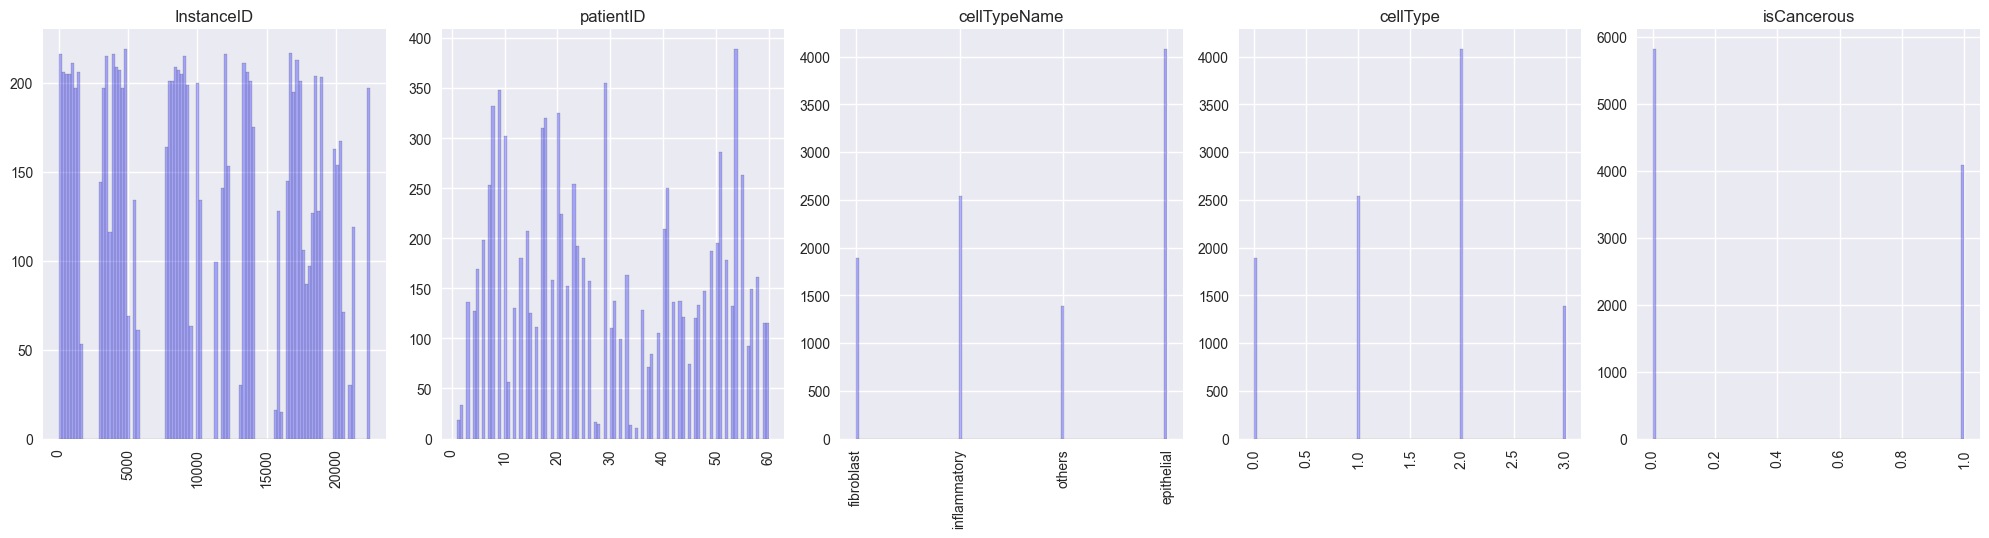

In [10]:
plt.figure(figsize=(20, 20))
cellsMainFrameEDA = cellsMainFrame.copy()
cellsMainFrameEDA = cellsMainFrameEDA.drop(['ImageName'], axis=1)
for i, col in enumerate(cellsMainFrameEDA.columns):
    plt.subplot(4, 5, i + 1)
    # Plot frequencies
    plt.hist(cellsMainFrameEDA[col], alpha=0.3, color='b', edgecolor='black', bins=100)
    plt.title(col)
    plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

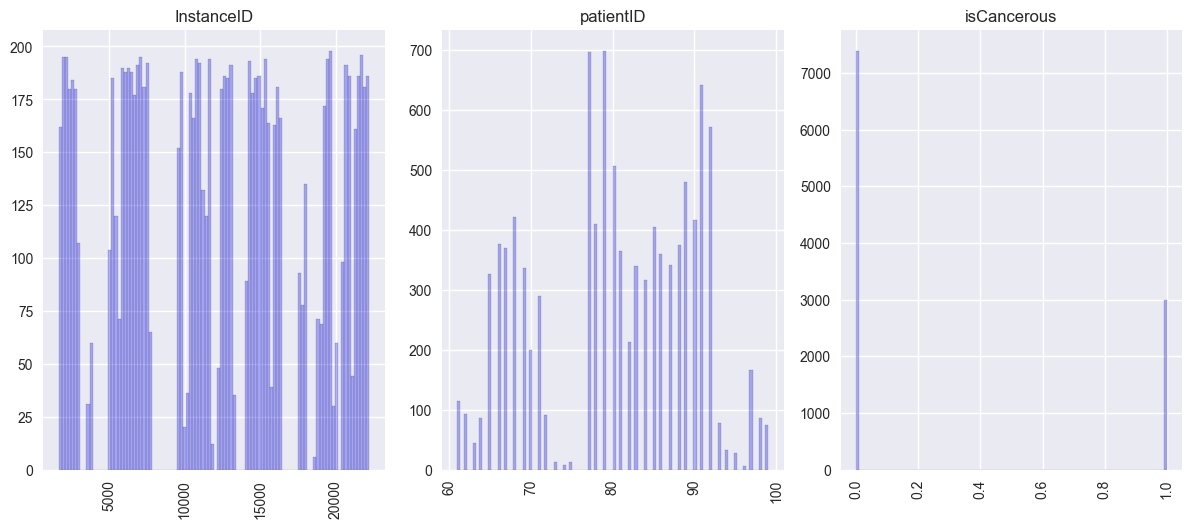

In [8]:
plt.figure(figsize=(20, 20))
cellsExtraFrameEDA = cellsExtraFrame.copy()
cellsExtraFrameEDA = cellsExtraFrameEDA.drop(['ImageName'], axis=1)
for i, col in enumerate(cellsExtraFrameEDA.columns):
    plt.subplot(4, 5, i + 1)
    # Plot frequencies
    plt.hist(cellsExtraFrameEDA[col], alpha=0.3, color='b', edgecolor='black', bins=100)
    plt.title(col)
    plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

**Observations:**
- *Main Dataset:*
- The patient with ID 54 has the most colon cell samples with just below 400. While the patient with ID 35 has the least with approximately 10.
- Cell type 2 i.e. epithelial is the most common cell type sampled with just over 4000. While cell types other than fibroblast, inflammatory and epithelia are the least common cell type sampled with just under 1500.
- Most data instances for the target variable `isCancerous` are from class 0 i.e. approximately 5900 cells are not cancerous and just over 4000 are.
- *Extra Dataset:*
- The patient with ID 79 has the most cell samples with approximately 700. While the patient with ID 96 has the least with approximately 5.
- Most data instances for the target variable `isCancerous` are also not cancerous with over 7000 and approximately 3000 that are.

## Relationship between Variables (isCancerous)

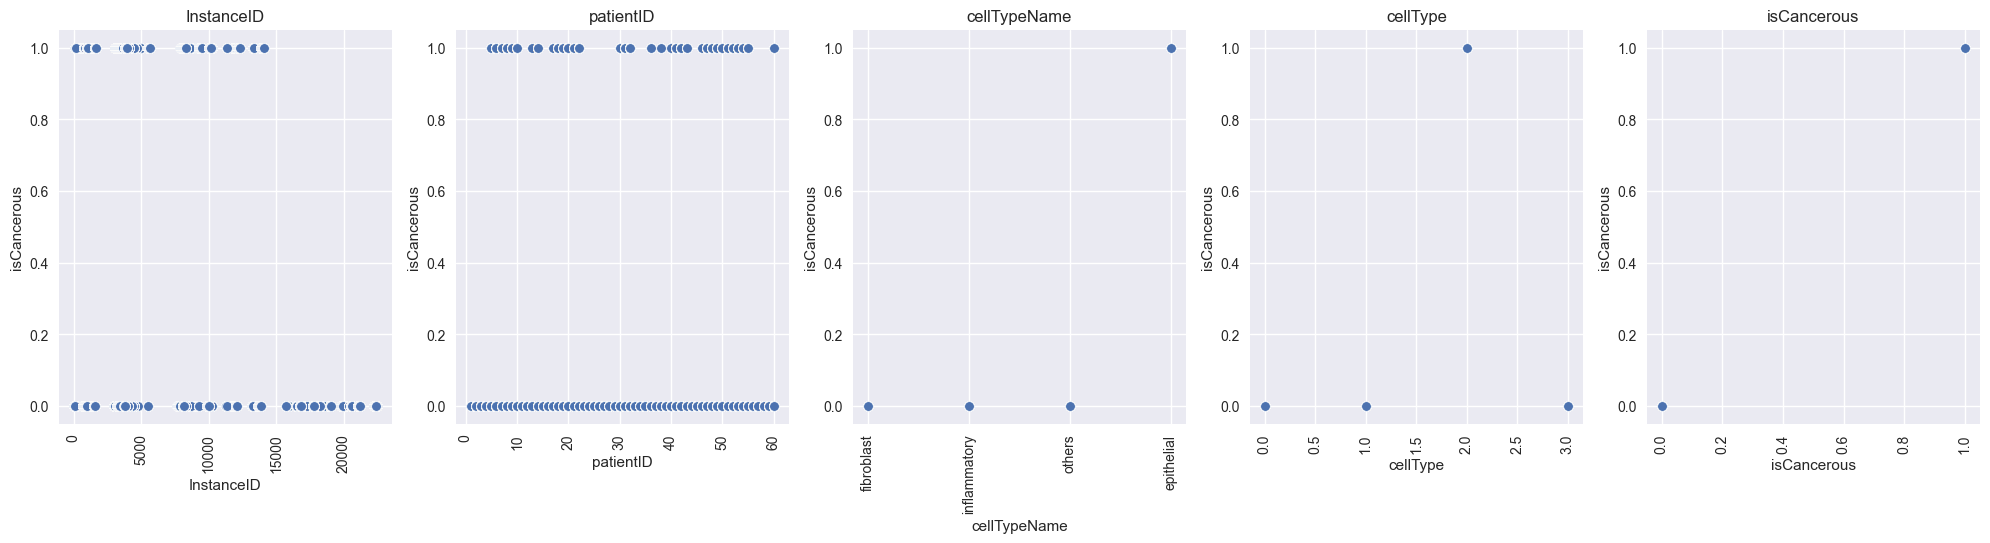

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cellsMainFrameEDA.columns):
    plt.subplot(4, 5, i + 1)
    plt.xticks(rotation='vertical')
    sns.scatterplot(data=cellsMainFrameEDA, x=col, y='isCancerous')
    plt.title(col)
plt.tight_layout()
plt.show()

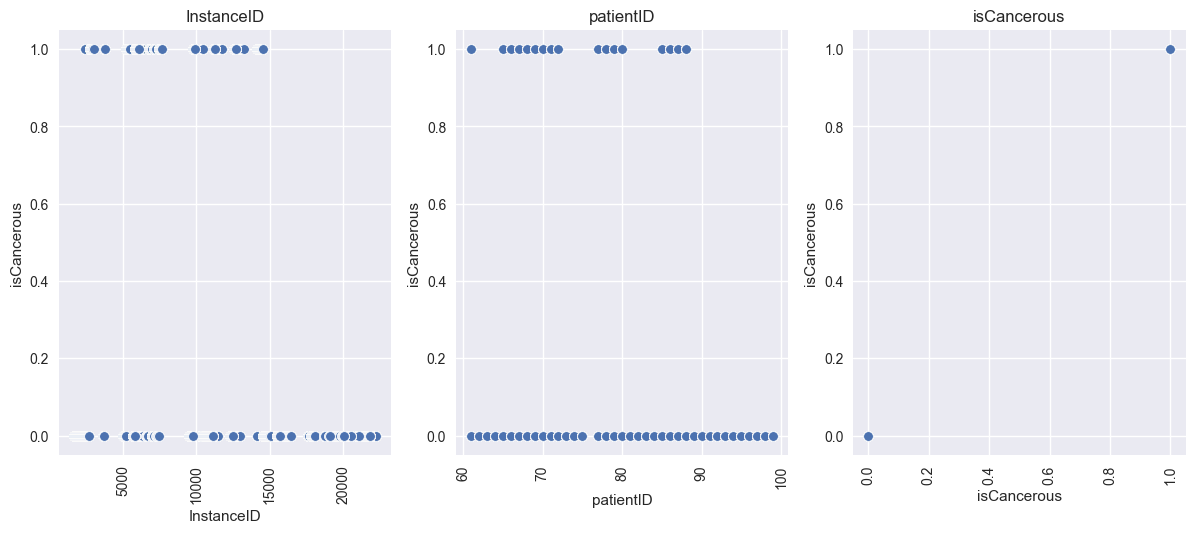

In [ ]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cellsExtraFrameEDA.columns):
    plt.subplot(4, 5, i + 1)
    plt.xticks(rotation='vertical')
    sns.scatterplot(data=cellsExtraFrameEDA, x=col, y='isCancerous')
    plt.title(col)
plt.tight_layout()
plt.show()

**Observations:**
- Most of the patients do not have cancerous cells.
- Only the epithelial cell type is cancerous, which means most patients do not have this cell type.

[np.int64(0), np.int64(1)]
[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196)]


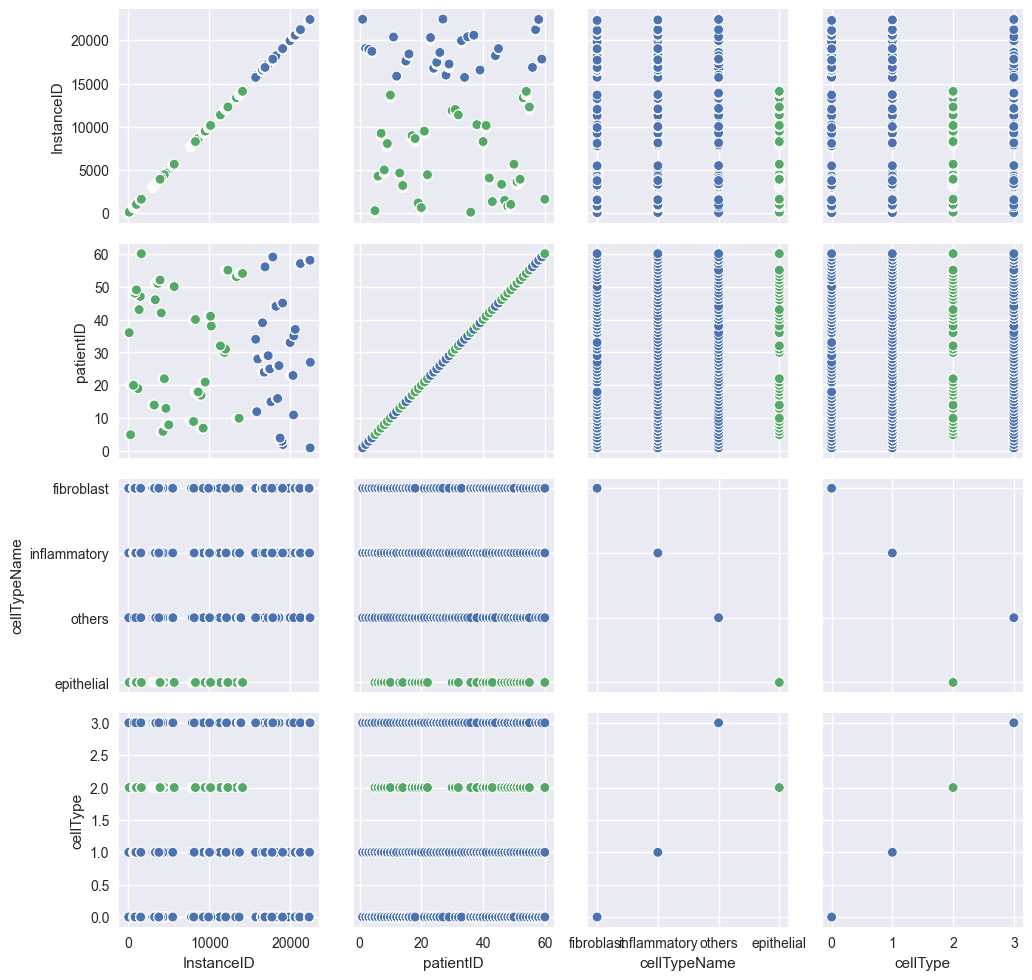

In [ ]:
# Plotting a more complete list of relationships showing decision boundaries separating classes
g = sns.PairGrid(cellsMainFrameEDA, vars=['InstanceID', 'patientID', 'cellTypeName', 'cellType'], hue='isCancerous')
print(g.hue_names)
print(g.palette)
g.map(sns.scatterplot)
plt.show()

[np.int64(0), np.int64(1)]
[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196)]


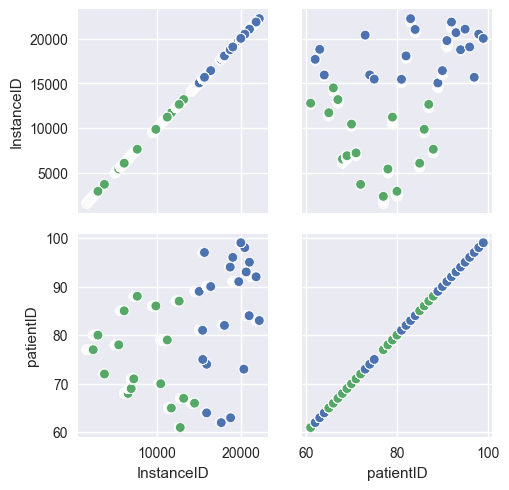

In [ ]:
# Plotting a more complete list of relationships showing decision boundaries separating classes
g = sns.PairGrid(cellsExtraFrameEDA, vars=['InstanceID', 'patientID'], hue='isCancerous')
print(g.hue_names)
print(g.palette)
g.map(sns.scatterplot)
plt.show()

**Observations:**
- The plots show that a linear decision boundary is able to separate the two classes. For example `InstanceID` vs. `patientID`.

## Relationship between Variables (cellTypeName)

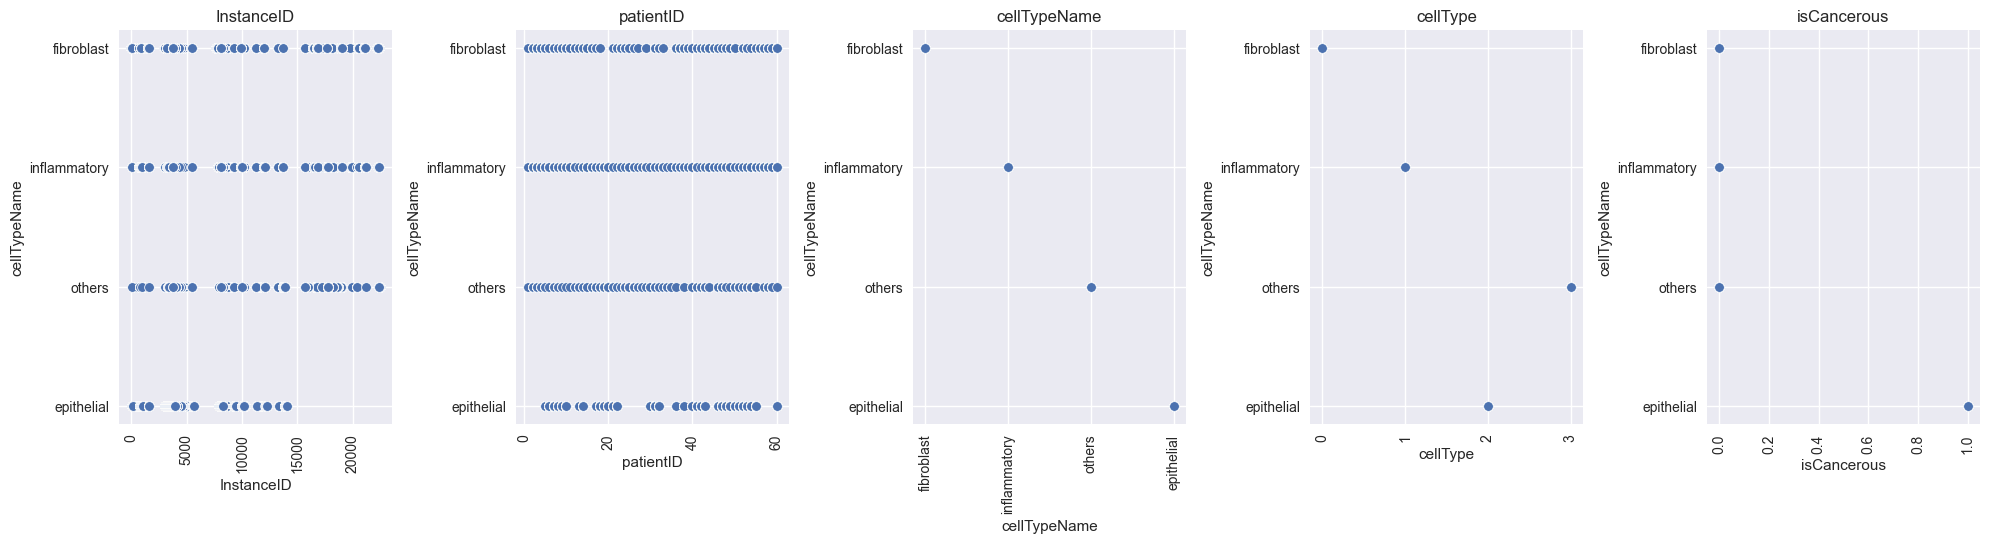

In [11]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cellsMainFrameEDA.columns):
    plt.subplot(4, 5, i + 1)
    plt.xticks(rotation='vertical')
    sns.scatterplot(data=cellsMainFrameEDA, x=col, y='cellTypeName')
    plt.title(col)
plt.tight_layout()
plt.show()

**Observations:**
- Instances past 15000 are not labelled as epithelial cell type.
- Patients with IDs across 0 to 60 have consistent number of labels for the cell types except epithelial.

['fibroblast', 'inflammatory', 'others', 'epithelial']
[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725), (0.3333333333333333, 0.6588235294117647, 0.40784313725490196), (0.7686274509803922, 0.3058823529411765, 0.3215686274509804), (0.5058823529411764, 0.4470588235294118, 0.6980392156862745)]


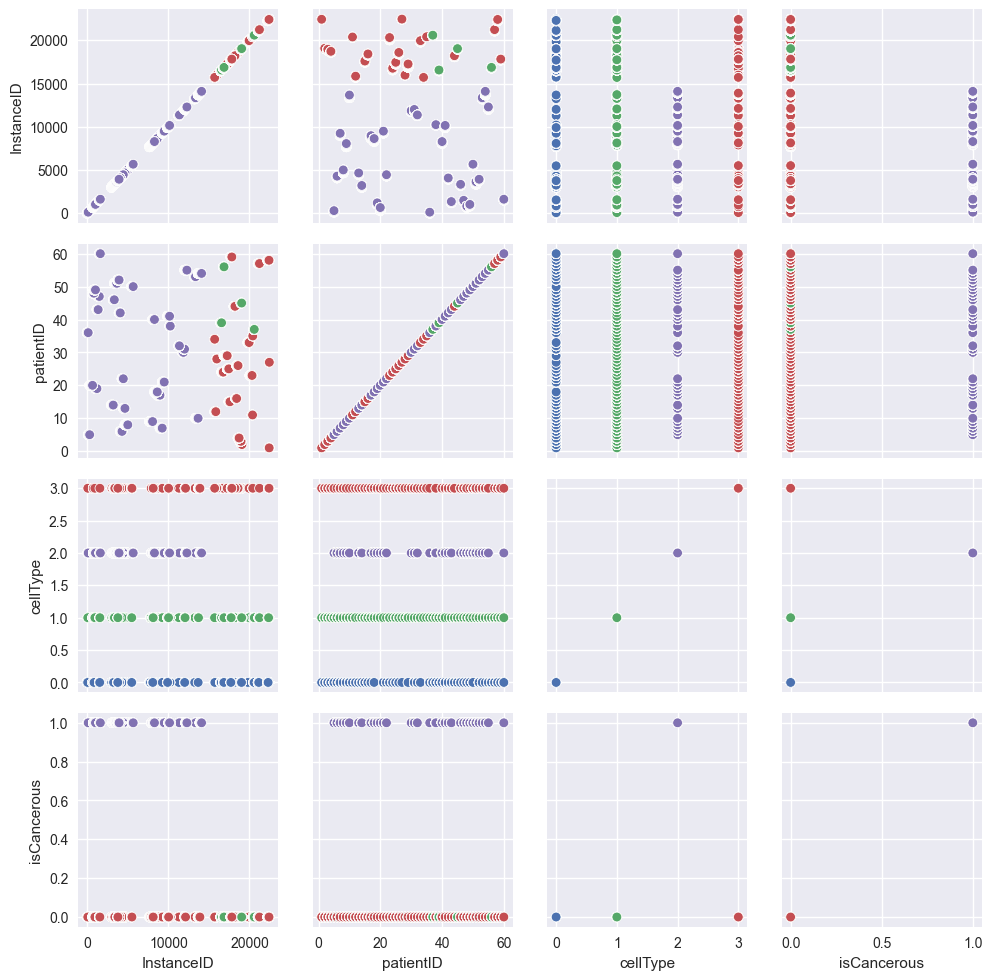

In [14]:
# Plotting a more complete list of relationships showing decision boundaries separating classes
g = sns.PairGrid(cellsMainFrameEDA, vars=['InstanceID', 'patientID', 'cellType', 'isCancerous'], hue='cellTypeName')
print(g.hue_names)
print(g.palette)
g.map(sns.scatterplot)
plt.show()

**Observations:**
- Many if not all fibroblast (blue hue) cells overlap with either inflammatory or others for the same `instanceID` and `patientID` combination.
- Also a complex non-linear decision boundary might be able to separate the classes for `instanceID` vs `patientID`.

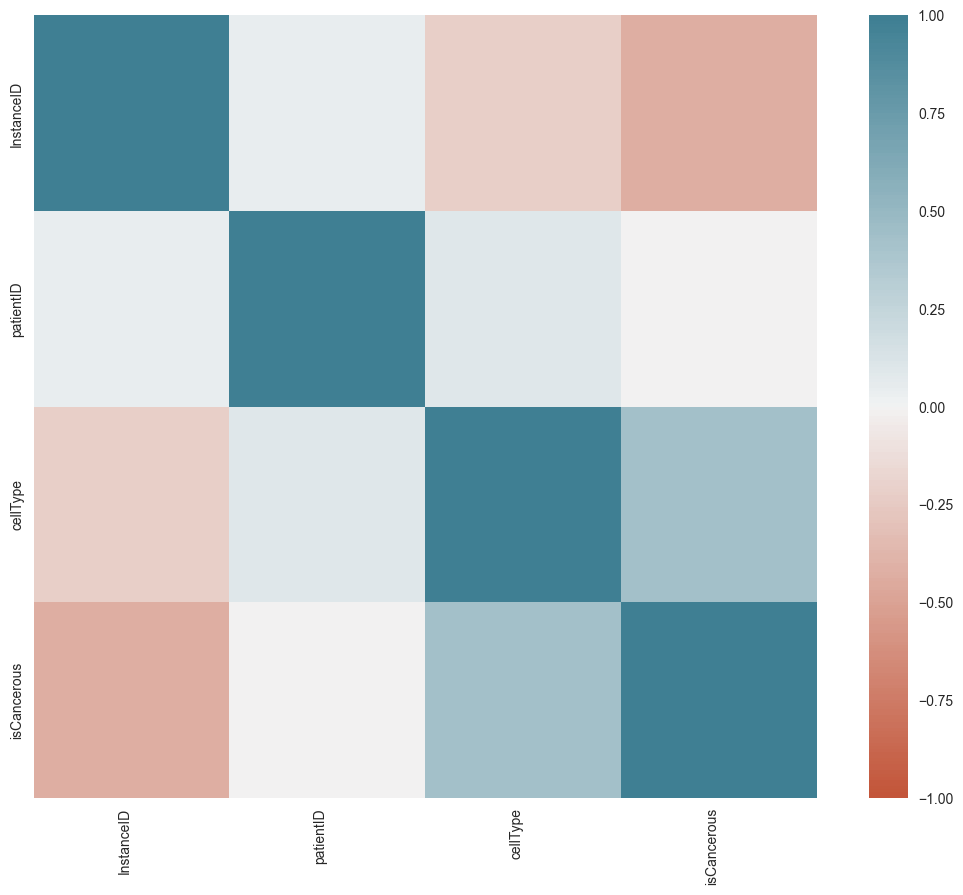

In [15]:
f, ax = plt.subplots(figsize=(11, 9))
cellsMainFrameEDA = cellsMainFrameEDA.drop(['cellTypeName'], axis=1)
corr = cellsMainFrameEDA.corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(20, 220, n=200), square=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
plt.tight_layout()
plt.show()

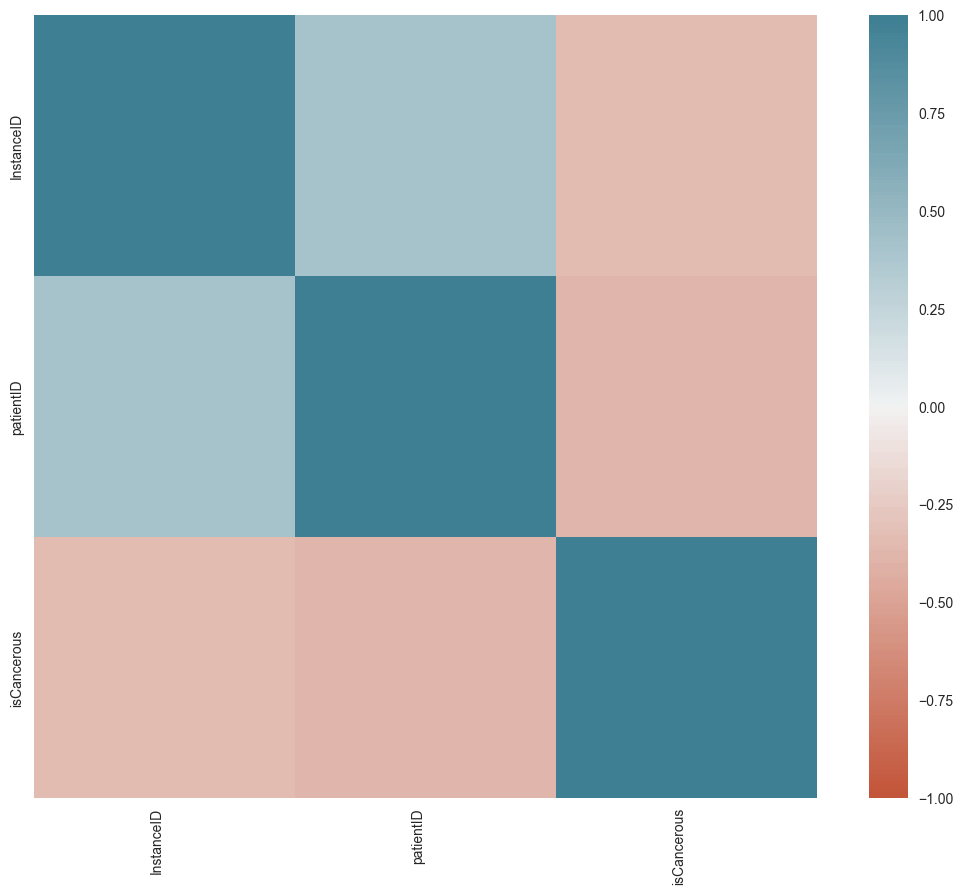

In [16]:
f, ax = plt.subplots(figsize=(11, 9))
corr = cellsExtraFrameEDA.corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(20, 220, n=200), square=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
plt.tight_layout()
plt.show()

**Observations:**
- *Main Dataset:*
- `cellType` has a correlation of approximately 0.15 with `patientID`.
- `cellType` has a correlation of approximately 0.5 with the target. While `InstanceID` has a high negative correlation with the target or approximately -0.5.
- *Extra Dataset:*
- `InstanceID` and `patientID` have a moderate negative correlation with the target of approximately -0.3.

## Plotting Images

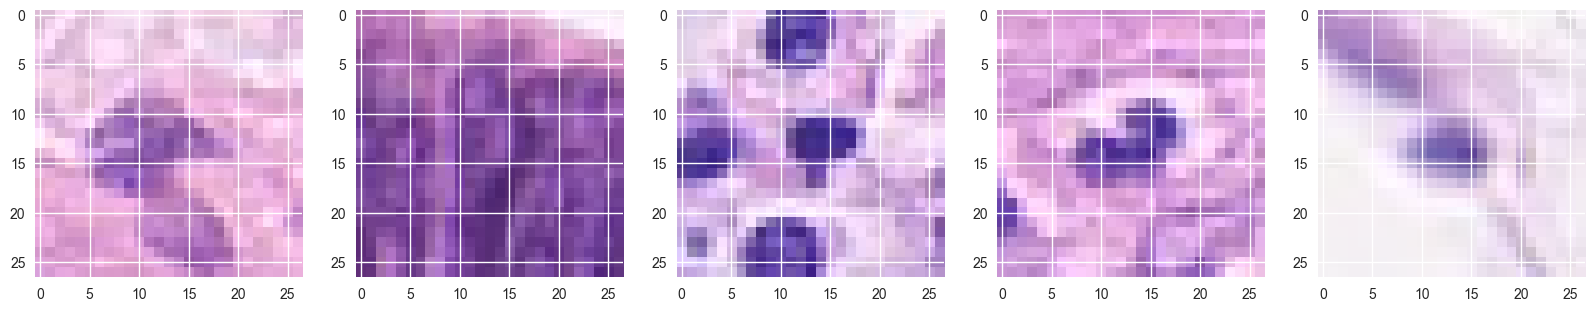

In [17]:
import matplotlib.image as mpimg

img = mpimg.imread('./data/images/1.png')
img2 = mpimg.imread('./data/images/5000.png')
img3 = mpimg.imread('./data/images/10000.png')
img4 = mpimg.imread('./data/images/15000.png')
img5 = mpimg.imread('./data/images/22444.png')
f, ax = plt.subplots(1, 5, figsize=(20, 20))
ax[0].imshow(img)
ax[1].imshow(img2)
ax[2].imshow(img3)
ax[3].imshow(img4)
ax[4].imshow(img5)
plt.show()

**Observations:**
- These randomly selected colon cell images have similar RGB pixels, but are different in appearance. For example, the third image has some large purple splodges, whereas the last image has a lot more fainter pixels.

# Data Pre-processing
The `cellTypeName` attribute can be derived from the `cellType` numeric attribute and therefore will not be used for training.
Even though the column `InstanceID` and `patientID` just contains the metadata about the dataset and it seems to have some useful information for predicting isCancerous and cellType and can try to first not remove them. I.e. train on both images and the metadata features.

In [4]:
cellsMainFrame = cellsMainFrame.drop(['cellTypeName'], axis=1)
cellsMainFrame.head()

,InstanceID,patientID,ImageName,cellType,isCancerous
0,22405,1,22405.png,0,0
1,22406,1,22406.png,0,0
2,22407,1,22407.png,0,0
3,22408,1,22408.png,0,0
4,22409,1,22409.png,0,0


## Data Splitting (isCancerous) (EDA)
## Random splitting

In [5]:
from sklearn.model_selection import train_test_split

# 80/20 split
# Drop cellType for this task
train_data_main, test_data_main = train_test_split(cellsMainFrame.drop(['cellType'], axis=1), test_size=0.2, 
    random_state=42
)

train_data_extra, test_data_extra = train_test_split(cellsExtraFrame, test_size=0.2, 
    random_state=42
)

print('Main Dataset:')
print('Train data: {}, Test Data: {}'.format(train_data_main.shape[0], test_data_main.shape[0]))

print('\nExtra Dataset:')
print('Train data: {}, Test Data: {}'.format(train_data_extra.shape[0], test_data_extra.shape[0]))

Main Dataset:
Train data: 7916, Test Data: 1980

Extra Dataset:
Train data: 8307, Test Data: 2077


## Conver to Tensors

In [6]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import os

class CellCancDataset(Dataset):
    def __init__(self, dataframe, directory, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.directory = directory
        self.transform = transform
        self.classes = sorted(self.dataframe['isCancerous'].unique())
        self.class_to_idx = {str(cls): i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.directory, row['ImageName'])
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[str(row['isCancerous'])]

        if self.transform:
            image = self.transform(image)

        return image, label


# Image size of 27 * 27
# Also no need for transforms.Normalize in the DataLoader as we scale later
train_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])

batch_size = 32

train_dataset_main = CellCancDataset(train_data_main, './data/images/', transform=train_transform)
test_dataset_main = CellCancDataset(test_data_main, './data/images/', transform=test_transform)

train_loader_main = DataLoader(train_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader_main = DataLoader(test_dataset_main, batch_size=batch_size, shuffle=False, num_workers=0)

train_dataset_extra = CellCancDataset(train_data_extra, './data/images/', transform=train_transform)
test_dataset_extra = CellCancDataset(test_data_extra, './data/images/', transform=test_transform)

train_loader_extra = DataLoader(train_dataset_extra, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader_extra = DataLoader(test_dataset_extra, batch_size=batch_size, shuffle=False, num_workers=0)

## Clustering (isCancerous Main Dataset)

In [9]:
import torch
from tqdm import tqdm

# First extract flattened features from dataloader
def extract_flat_features(dataloader):
    all_features = []
    all_labels = []

    for imgs, lbls in tqdm(dataloader):
        B = imgs.size(0)
        # flatten to (Batch, 2187) 1-dimensional shape
        feats = imgs.view(B, -1)
        all_features.append(feats)
        all_labels.append(lbls)

    return torch.cat(all_features), torch.cat(all_labels)

X_train_main_canc, y_train_main_canc = extract_flat_features(train_loader_main)

100%|██████████| 186/186 [00:07<00:00, 24.38it/s]


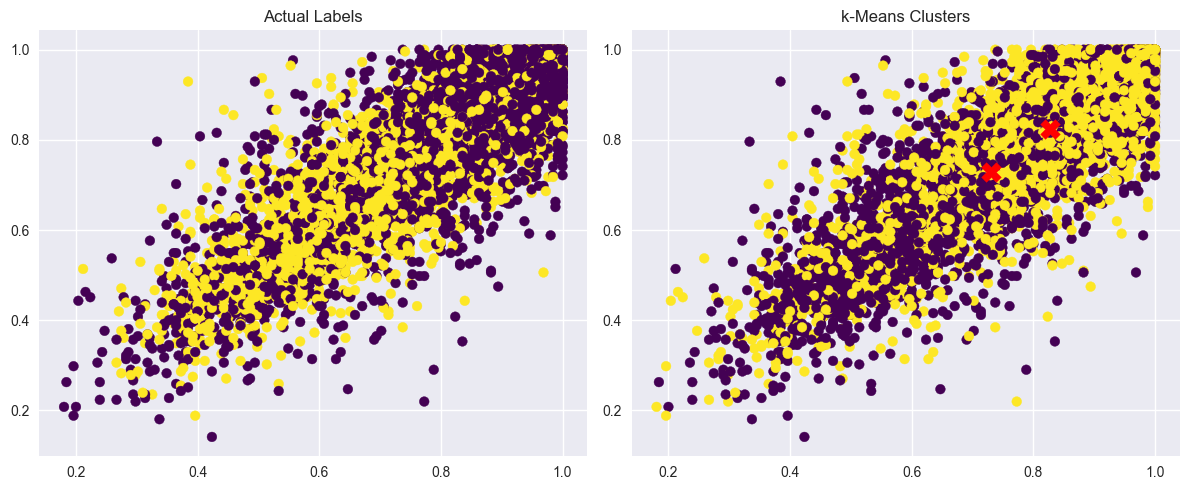

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)

kmeans.fit(X_train_main_canc)
y_kmeans = kmeans.predict(X_train_main_canc)

# Cluster centers
centers = kmeans.cluster_centers_

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual labels
axes[0].scatter(X_train_main_canc[:, 0], X_train_main_canc[:, 1], c=y_train_main_canc, cmap='viridis')

axes[0].set_title('Actual Labels')

# KMeans predicted clusters
axes[1].scatter(X_train_main_canc[:, 0], X_train_main_canc[:, 1], c=y_kmeans, cmap='viridis')

# Plot cluster centers
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')

axes[1].set_title('k-Means Clusters')

plt.tight_layout()
plt.show()

**Observations:**
- The two clusters found by k-means very roughly match the two classes.
- Some points are mixed.

## Clustering (isCancerous Extra Dataset)

In [23]:
X_train_extra_canc, y_train_extra_canc = extract_flat_features(train_loader_extra)

100%|██████████| 260/260 [00:13<00:00, 19.53it/s]


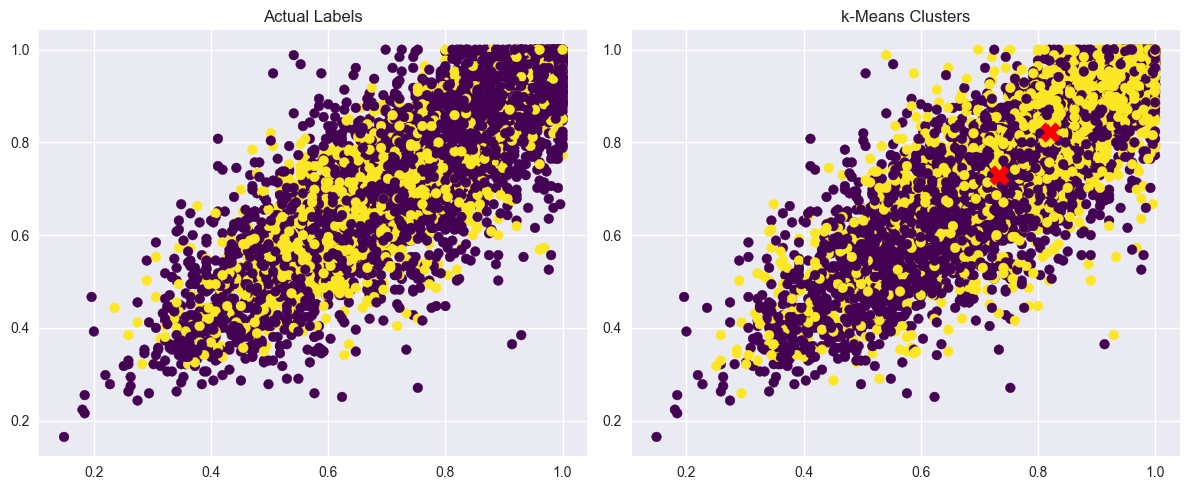

In [24]:
kmeans = KMeans(n_clusters=2, random_state=0)

kmeans.fit(X_train_extra_canc)
y_kmeans = kmeans.predict(X_train_extra_canc)

# Cluster centers
centers = kmeans.cluster_centers_

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual labels
axes[0].scatter(X_train_extra_canc[:, 0], X_train_extra_canc[:, 1], c=y_train_extra_canc, cmap='viridis')

axes[0].set_title('Actual Labels')

# KMeans predicted clusters
axes[1].scatter(X_train_extra_canc[:, 0], X_train_extra_canc[:, 1], c=y_kmeans, cmap='viridis')

# Plot cluster centers
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')

axes[1].set_title('k-Means Clusters')

plt.tight_layout()
plt.show()

**Observations:**
- Again, the two clusters found by k-means very roughly match the two classes.
- Some points are mixed.

## Data Splitting (cellTypeName) (EDA)
## Random splitting

In [7]:
from sklearn.model_selection import train_test_split

# 80/20 split
# Drop isCancerous for this task
train_data_main, test_data_main = train_test_split(cellsMainFrame.drop(['isCancerous'], axis=1), test_size=0.2, random_state=42)

print('Train data: {}, Test Data: {}'.format(train_data_main.shape[0], test_data_main.shape[0]))

Train data: 7916, Test Data: 1980


In [8]:
import os
from PIL import Image
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms

class CellTypeDataset(Dataset):
    def __init__(self, dataframe, directory, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.directory = directory
        self.transform = transform
        self.classes = sorted(self.dataframe['cellType'].unique())
        self.class_to_idx = {str(cls): i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.directory, row['ImageName'])
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[str(row['cellType'])]

        if self.transform:
            image = self.transform(image)

        return image, label

train_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])

batch_size = 32

train_dataset_main = CellTypeDataset(train_data_main, './data/images/', transform=train_transform)
test_dataset_main = CellTypeDataset(test_data_main, './data/images/', transform=test_transform)

train_loader_main = DataLoader(train_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader_main = DataLoader(test_dataset_main, batch_size=batch_size, shuffle=False, num_workers=0)

## Clustering (cellTypeName)

In [27]:
X_train_main_cell, y_train_main_cell = extract_flat_features(train_loader_main)

100%|██████████| 248/248 [00:05<00:00, 45.00it/s]


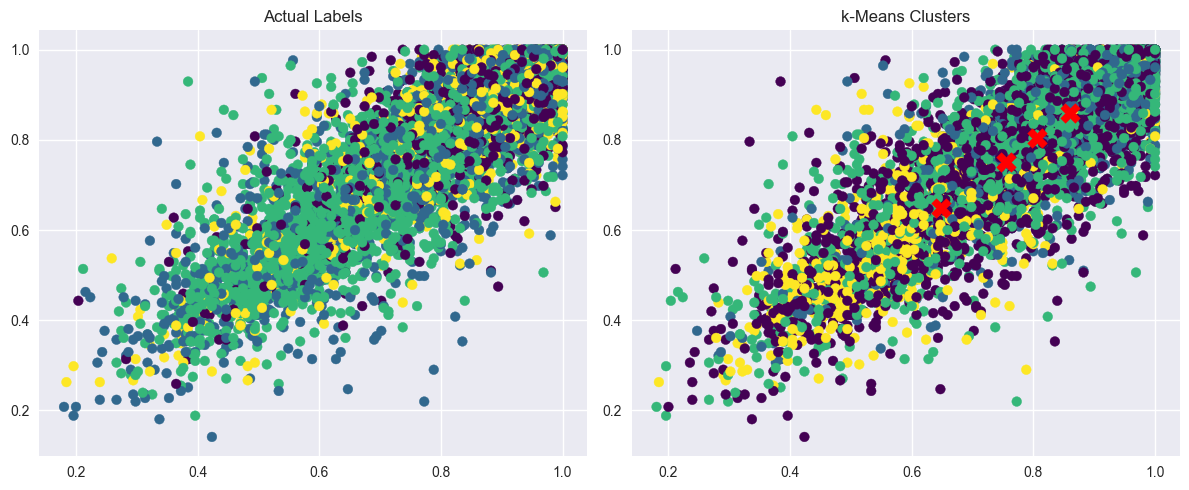

In [28]:
kmeans = KMeans(n_clusters=4, random_state=0)

kmeans.fit(X_train_main_cell)
y_kmeans = kmeans.predict(X_train_main_cell)

# Cluster centers
centers = kmeans.cluster_centers_

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual labels
axes[0].scatter(X_train_main_cell[:, 0], X_train_main_cell[:, 1], c=y_train_main_cell, cmap='viridis')

axes[0].set_title('Actual Labels')

# KMeans predicted clusters
axes[1].scatter(X_train_main_cell[:, 0], X_train_main_cell[:, 1], c=y_kmeans, cmap='viridis')

# Plot cluster centers
axes[1].scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')

axes[1].set_title('k-Means Clusters')

plt.tight_layout()
plt.show()

**Observations:**
- The cluster boundaries do not match the true labels and cut across categories.
- Also has overlapping class structure and are not linearly separable.

# Performance metric

In [10]:
from sklearn.metrics import f1_score

# Macro averaged f1 score to give equal weight to all four classes and as per the task
def get_f1_scores(clf, train_X, train_y, val_X, val_y):
    train_pred = clf.predict(train_X)
    val_pred = clf.predict(val_X)
    
    train_f1 = f1_score(train_y, train_pred, average='macro')
    val_f1 = f1_score(val_y, val_pred, average='macro')
    
    return train_f1, val_f1

# isCancerous Task
# Data Splitting
## Random splitting (Hold-out validation)

In [11]:
# As per the task use Hold-out validation (60/20/20)

# Also remove cellType as per the task is analysed separately and would way to easy for the model (type 2 always equals cancer).
X_temp, X_test_main, y_temp, y_test_main = train_test_split(cellsMainFrame.drop(['ImageName', 'cellType', 'isCancerous'], axis=1), 
    cellsMainFrame['isCancerous'], test_size=0.2, shuffle=True, random_state=0
)
X_train_main, X_val_main, y_train_main, y_val_main = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=True, random_state=0)

X_temp, X_test_extra, y_temp, y_test_extra = train_test_split(cellsExtraFrame.drop(['ImageName', 'isCancerous'], axis=1), 
    cellsExtraFrame['isCancerous'], test_size=0.2, shuffle=True, random_state=0
)
X_train_extra, X_val_extra, y_train_extra, y_val_extra = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=True, random_state=0)

# Handle images separately
train_data_main, test_data_main = train_test_split(cellsMainFrame.drop(['InstanceID', 'patientID', 'cellType'], axis=1), test_size=0.2, 
    random_state=0
)
train_data_main, val_data_main = train_test_split(train_data_main, test_size=0.25, shuffle=True, random_state=0)

train_data_extra, test_data_extra = train_test_split(cellsExtraFrame.drop(['InstanceID', 'patientID'], axis=1), test_size=0.2, 
    random_state=0
)
train_data_extra, val_data_extra = train_test_split(train_data_extra, test_size=0.25, shuffle=True, random_state=0)

print('Main Dataset:')
print(f'Train size: {X_train_main.shape[0]}')
print(f'Validation size: {X_val_main.shape[0]}')
print(f'Test size: {X_test_main.shape[0]}')
print('\nExtra Dataset:')
print(f'Train size: {X_train_extra.shape[0]}')
print(f'Validation size: {X_val_extra.shape[0]}')
print(f'Test size: {X_test_extra.shape[0]}')

Main Dataset:
Train size: 5937
Validation size: 1979
Test size: 1980

Extra Dataset:
Train size: 6230
Validation size: 2077
Test size: 2077


In [12]:
# Image size of 27 * 27
train_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])
val_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])

batch_size = 32

train_dataset_main = CellCancDataset(train_data_main, './data/images/', transform=train_transform)
val_dataset_main = CellCancDataset(val_data_main, './data/images/', transform=val_transform)
test_dataset_main = CellCancDataset(test_data_main, './data/images/', transform=test_transform)

train_loader_main = DataLoader(train_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_main = DataLoader(val_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader_main = DataLoader(test_dataset_main, batch_size=batch_size, shuffle=False, num_workers=0)

train_dataset_extra = CellCancDataset(train_data_extra, './data/images/', transform=train_transform)
val_dataset_extra = CellCancDataset(val_data_extra, './data/images/', transform=val_transform)
test_dataset_extra = CellCancDataset(test_data_extra, './data/images/', transform=test_transform)

train_loader_extra = DataLoader(train_dataset_extra, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_extra = DataLoader(val_dataset_extra, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader_extra = DataLoader(test_dataset_extra, batch_size=batch_size, shuffle=False, num_workers=0)

X_train_main_canc, y_train_main_canc = extract_flat_features(train_loader_main)
X_val_main_canc, y_val_main_canc = extract_flat_features(val_loader_main)
X_test_main_canc, y_test_main_canc = extract_flat_features(test_loader_main)

# Combine images with rest of features
X_train_main = np.concatenate([X_train_main.values, X_train_main_canc.numpy()], axis=1)
X_val_main = np.concatenate([X_val_main.values, X_val_main_canc.numpy()], axis=1)
X_test_main = np.concatenate([X_test_main.values, X_test_main_canc.numpy()], axis=1)

X_train_extra_canc, y_train_extra_canc = extract_flat_features(train_loader_extra)
X_val_extra_canc, y_val_extra_canc = extract_flat_features(val_loader_extra)
X_test_extra_canc, y_test_extra_canc = extract_flat_features(test_loader_extra)

# Combine images with rest of features
X_train_extra = np.concatenate([X_train_extra.values, X_train_extra_canc.numpy()], axis=1)
X_val_extra = np.concatenate([X_val_extra.values, X_val_extra_canc.numpy()], axis=1)
X_test_extra = np.concatenate([X_test_extra.values, X_test_extra_canc.numpy()], axis=1)

100%|██████████| 65/65 [00:02<00:00, 29.47it/s]


# isCancerous Task
# Simple decision tree training
Feature scaling is not necessary for decision tree classifiers as the algorithm produces the same splits regardless of scale.

In [11]:
from sklearn import tree

# Can increase depth for better prediction performance (use as hyperparameter for tuning below)
tree_max_depth = 2

# Class weight balanced to balance the uneven classes from EDA
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=tree_max_depth, class_weight='balanced', random_state=0)
clf = clf.fit(X_train_main, y_train_main)

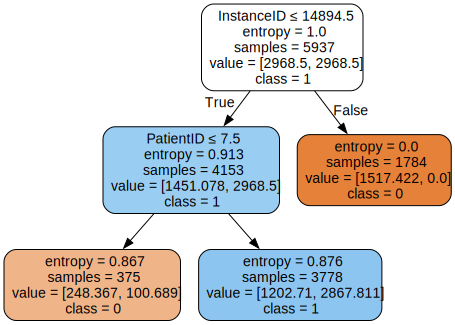

In [15]:
import graphviz

pixel_features = [f'pixel_{i}' for i in range(X_train_main_canc.shape[1])]
meta_features = ['InstanceID', 'PatientID']
feature_names = meta_features + pixel_features

def get_tree_2_plot(clf):
    dot_data = tree.export_graphviz(clf, out_file=None, feature_names=feature_names, class_names=['0', '1'], filled=True, rounded=True, 
        special_characters=True
    )
    graph = graphviz.Source(dot_data)
    
    return graph

DtreeMain = get_tree_2_plot(clf)
DtreeMain

In [34]:
train_f1, val_f1 = get_f1_scores(clf, X_train_main, y_train_main, X_val_main, y_val_main)
print('Main Dataset:')
print('Train f1 score: {:.3f}'.format(train_f1))
print('Val f1 score: {:.3f}'.format(val_f1))

Main Dataset:
Train f1 score: 0.747
Val f1 score: 0.755


In [35]:
clf_extra = tree.DecisionTreeClassifier(criterion='entropy', max_depth=tree_max_depth, class_weight='balanced', random_state=0)
clf_extra = clf_extra.fit(X_train_extra, y_train_extra)

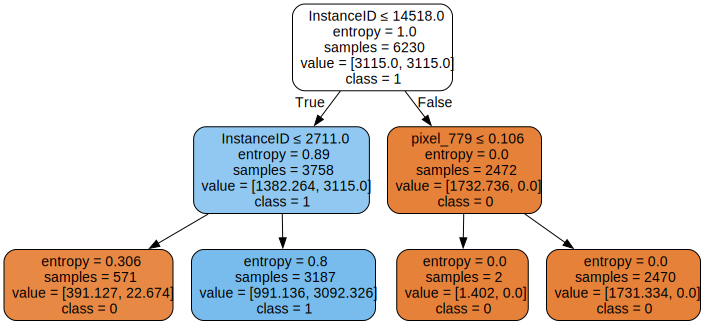

In [36]:
DtreeExtra = get_tree_2_plot(clf_extra)
DtreeExtra

In [37]:
train_f1, val_f1 = get_f1_scores(clf, X_train_extra, y_train_extra, X_val_extra, y_val_extra)
print('Extra Dataset')
print('Train f1 score: {:.3f}'.format(train_f1))
print('Val f1 score: {:.3f}'.format(val_f1))

Extra Dataset
Train f1 score: 0.650
Val f1 score: 0.643


**Observations:**
- Interestingly `InstanceID` is the most important feature for both sets as it is immediately split at the root, so keeping it seems relevant.
- The root nodes are perfectly balanced across the two classes, which provides the high entropy.
- The `patientID` is the second most informative feature (left branch of main set).
- So far no pixels suggest to be important according to the main set DT.
- `pixel_779` suggests that is useful for predicting not cancerous in the extra set.
- There is some slight overfitting with the results with macro-averaged f1 scores not meeting the quota; can be improved with hyperparameter tuning.

## Hyperparameter tuning

In [12]:
from sklearn.model_selection import GridSearchCV

# Tune max_depth as it is typically the most influencial factor for DT performance
parameter = {'max_depth': np.arange(2, 15, 1)}

dt_clf = tree.DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=0)
grid_clf = GridSearchCV(dt_clf, parameter, scoring='f1_macro', n_jobs=-1)
grid_clf.fit(X_train_main, y_train_main)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 2, 3..., 12, 13, 14])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [39]:
pd.DataFrame(grid_clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.105193,0.354193,0.024483,0.009124,2,{'max_depth': 2},0.744230,0.733080,0.769797,0.743844,0.745143,0.747219,0.012119,13
1,2.885739,0.397070,0.019042,0.003314,3,{'max_depth': 3},0.747465,0.741251,0.778100,0.745483,0.753392,0.753138,0.013079,12
2,3.532395,0.401202,0.023460,0.003457,4,{'max_depth': 4},0.753537,0.750843,0.780673,0.753307,0.757713,0.759214,0.010954,11
3,3.859351,0.052173,0.022464,0.002478,5,{'max_depth': 5},0.768057,0.789954,0.786639,0.766905,0.794029,0.781117,0.011383,10
4,4.703853,0.025387,0.026843,0.009693,6,{'max_depth': 6},0.805602,0.802829,0.811274,0.805188,0.798487,0.804676,0.004156,9
5,5.897455,0.205486,0.019675,0.006414,7,{'max_depth': 7},0.855774,0.852851,0.825514,0.810444,0.860705,0.841057,0.019598,8
6,7.171681,0.401860,0.021848,0.004728,8,{'max_depth': 8},0.884002,0.849090,0.840508,0.840416,0.855776,0.853958,0.016087,7
7,7.828864,0.197106,0.020943,0.001608,9,{'max_depth': 9},0.902494,0.897958,0.883083,0.872463,0.905090,0.892217,0.012474,6
8,8.364863,0.317724,0.026049,0.008239,10,{'max_depth': 10},0.912515,0.887819,0.892984,0.887989,0.902215,0.896704,0.009477,5
9,8.859589,0.181714,0.019901,0.003467,11,{'max_depth': 11},0.920897,0.916664,0.912390,0.896639,0.923669,0.914052,0.009509,4


In [13]:
print(grid_clf.best_score_)
print(grid_clf.best_params_)

clf_main = grid_clf.best_estimator_

0.947064018379705
{'max_depth': np.int64(14)}


In [41]:
dt_clf_extra = tree.DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=0)
grid_clf = GridSearchCV(dt_clf_extra, parameter, scoring='f1_macro', n_jobs=-1)
grid_clf.fit(X_train_extra, y_train_extra)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 2, 3..., 12, 13, 14])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [42]:
pd.DataFrame(grid_clf.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.093109,0.156798,0.025123,0.001439,2,{'max_depth': 2},0.754475,0.750866,0.763863,0.762350,0.774641,0.761239,0.008259,12
1,2.662285,0.159307,0.022223,0.006392,3,{'max_depth': 3},0.754475,0.750866,0.763863,0.762350,0.774641,0.761239,0.008259,12
2,3.197004,0.237996,0.019721,0.003531,4,{'max_depth': 4},0.758131,0.753600,0.765697,0.763267,0.776483,0.763436,0.007749,11
3,3.666673,0.234743,0.022067,0.004889,5,{'max_depth': 5},0.775562,0.771764,0.787761,0.783779,0.802508,0.784275,0.010745,10
4,4.177059,0.109454,0.020743,0.003793,6,{'max_depth': 6},0.777844,0.772523,0.787761,0.786070,0.802508,0.785341,0.010214,9
5,4.798089,0.223226,0.020543,0.003908,7,{'max_depth': 7},0.792354,0.786996,0.848913,0.799872,0.868239,0.819275,0.032921,8
6,5.159577,0.268970,0.019657,0.002982,8,{'max_depth': 8},0.803726,0.800035,0.868597,0.814567,0.879548,0.833295,0.033814,7
7,5.512902,0.212764,0.020352,0.004624,9,{'max_depth': 9},0.803726,0.800035,0.891869,0.814567,0.898713,0.841782,0.044004,6
8,5.949546,0.342975,0.019139,0.003226,10,{'max_depth': 10},0.830202,0.824086,0.922575,0.832564,0.910602,0.864006,0.043189,5
9,6.174835,0.295179,0.019355,0.002264,11,{'max_depth': 11},0.830202,0.824086,0.933096,0.832564,0.927913,0.869572,0.049855,4


In [43]:
print(grid_clf.best_score_)
print(grid_clf.best_params_)

clf_extra = grid_clf.best_estimator_

0.9357025488076257
{'max_depth': np.int64(14)}


In [44]:
train_f1, val_f1 = get_f1_scores(clf_main, X_train_main, y_train_main, X_val_main, y_val_main)
print('Main Dataset:')
print('Train f1 score: {:.3f}'.format(train_f1))
print('Val f1 score: {:.3f}'.format(val_f1))

Main Dataset:
Train f1 score: 0.963
Val f1 score: 0.961


In [45]:
train_f1, val_f1 = get_f1_scores(clf_extra, X_train_extra, y_train_extra, X_val_extra, y_val_extra)
print('Main Dataset:')
print('Train f1 score: {:.3f}'.format(train_f1))
print('Val f1 score: {:.3f}'.format(val_f1))

Main Dataset:
Train f1 score: 0.914
Val f1 score: 0.914


**Observations:**
- Tree depth of 14 seems to be the most contributing parameter value for performance.
- Interestingly, no or very miniscule overfitting with the extra data set.
- Meets the quote of 0.9 for isCancerous, see if new unseen patients has the same result on hold-out test data.

In [46]:
train_f1, test_f1 = get_f1_scores(clf_main, X_train_main, y_train_main, X_test_main, y_test_main)
print('Main Dataset:')
print('Train f1 score: {:.3f}'.format(train_f1))
print('Test f1 score: {:.3f}'.format(test_f1))

Main Dataset:
Train f1 score: 0.963
Test f1 score: 0.961


              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1177
           1       0.92      0.99      0.96       803

    accuracy                           0.96      1980
   macro avg       0.96      0.97      0.96      1980
weighted avg       0.96      0.96      0.96      1980



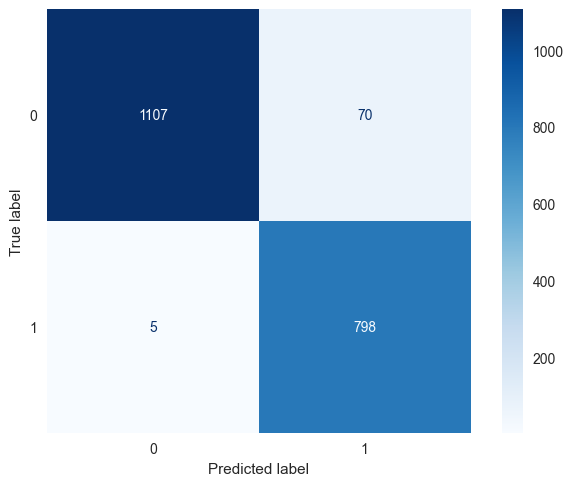

In [47]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

test_pred = clf_main.predict(X_test_main)

print(classification_report(y_test_main, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf_main, X_test_main, y_test_main, cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

In [48]:
train_f1, test_f1 = get_f1_scores(clf_extra, X_train_extra, y_train_extra, X_test_extra, y_test_extra)
print('Extra Dataset:')
print('Train f1 score: {:.3f}'.format(train_f1))
print('Test f1 score: {:.3f}'.format(test_f1))

Extra Dataset:
Train f1 score: 0.914
Test f1 score: 0.903


              precision    recall  f1-score   support

           0       1.00      0.88      0.94      1501
           1       0.77      1.00      0.87       576

    accuracy                           0.92      2077
   macro avg       0.88      0.94      0.90      2077
weighted avg       0.94      0.92      0.92      2077



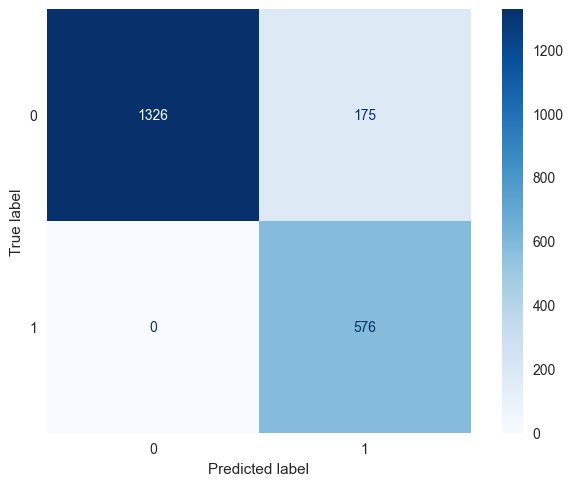

In [49]:
test_pred = clf_extra.predict(X_test_extra)

print(classification_report(y_test_extra, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf_extra, X_test_extra, y_test_extra, cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

**Observations:**
- Excellent performance with above 0.9 macro-averaged f1 scores for new unseen patients, with the extra data slightly worse.
- Both sets predict a small amount of cancerous when it is actually not cancerous (i.e. Main: 71, Extra 175).
- Extra dataset DT performed the best in terms of predicting not cancerous with 0 data being misclassified i.e. a precision of 1.00 for the 0 class.

## Feature importance

<Figure size 1000x1000 with 0 Axes>

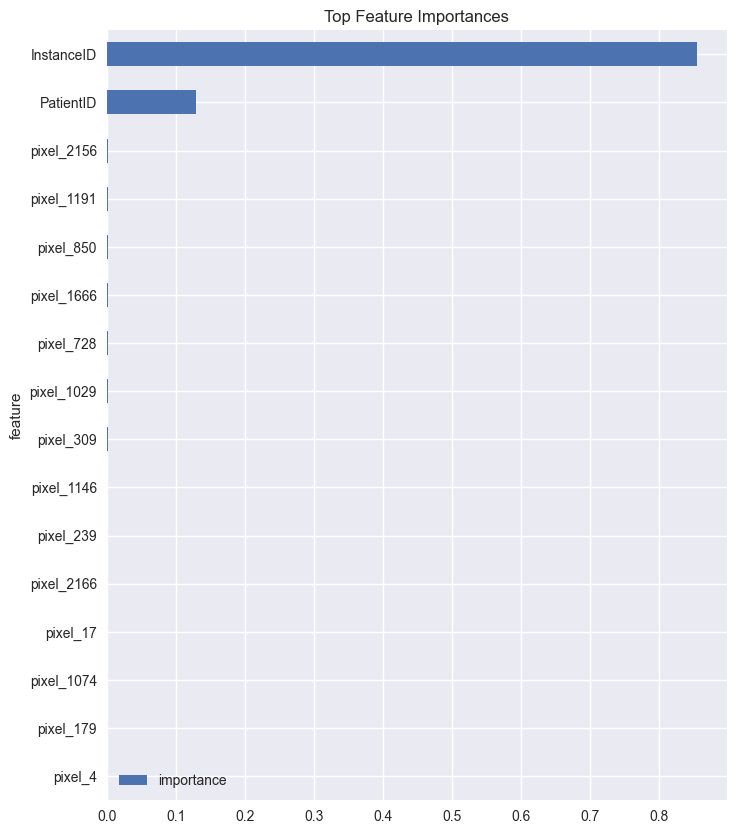

In [16]:
tree_feature_importances = clf_main.feature_importances_

plt.figure(figsize=(10, 10))
fi = pd.DataFrame({'feature': feature_names, 'importance': tree_feature_importances}).sort_values('importance', ascending=False)

top_k = 16
fi.head(top_k).plot(kind='barh', x='feature', y='importance', figsize=(8, 10))
plt.gca().invert_yaxis()
plt.title('Top Feature Importances')
plt.show()

**Observations:**
- The model seems to only heavily rely on `InstanceID` and `patientID` to predict the target.
- It seems there are no other attributes (i.e. images pixels) it heavily relies on, even though this is an image classification task.
- This could mean the images generate a lot of unecessary noise and do not have a good relationship with the target for this DT model.

# Baseline SVM model (isCancerous)

In [51]:
# Applying Standard Scaler is recommended as it reduces sensitivity to extreme outliers in the attributes (incl. pixels)
# Also no need for transforms.Normalize in the DataLoader as we scale all incl. metadata here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# train on just X_train if tuning hyperparameters for hold-out
X_train_main = np.concatenate([X_train_main, X_val_main], axis=0)
y_train_main = np.concatenate([y_train_main, y_val_main], axis=0)
scaler.fit(X_train_main)

X_train_main = scaler.transform(X_train_main)
X_test_main = scaler.transform(X_test_main)

In [52]:
scaler = StandardScaler()
X_train_extra = np.concatenate([X_train_extra, X_val_extra], axis=0)
y_train_extra = np.concatenate([y_train_extra, y_val_extra], axis=0)
scaler.fit(X_train_extra)

X_train_extra = scaler.transform(X_train_extra)
X_test_extra = scaler.transform(X_test_extra)

## Testing the model

In [53]:
from sklearn.svm import LinearSVC

# Could tune hyperparameters such as kernel if but unecessary since we achieved the target score of 0.9 for this task
# LinearSVC much faster than SVC(kernel='linear')
clf_main = LinearSVC(C=1.0, random_state=0, class_weight='balanced')
clf_main.fit(X_train_main, y_train_main)

train_f1, test_f1 = get_f1_scores(clf_main, X_train_main, y_train_main, X_test_main, y_test_main)
print('Train F1-Score score: {:.3f}'.format(train_f1))
print('Test F1-Score score: {:.3f}'.format(test_f1))

Train F1-Score score: 0.799
Test F1-Score score: 0.618


In [54]:
clf_extra = LinearSVC(C=1.0, random_state=0, class_weight='balanced')
clf_extra.fit(X_train_extra, y_train_extra)

train_f1, test_f1 = get_f1_scores(clf_extra, X_train_extra, y_train_extra, X_test_extra, y_test_extra)
print('Train F1-Score score: {:.3f}'.format(train_f1))
print('Test F1-Score score: {:.3f}'.format(test_f1))

Train F1-Score score: 0.802
Test F1-Score score: 0.629


**Observations:**
- Higher training scores, so overfitting with not great validation scores.
- Performed slightly worse in terms of validation/test scores for untuned DT (depth 2).
- Again could be improved by hyperparameter tuning.

              precision    recall  f1-score   support

           0       0.70      0.64      0.67      1177
           1       0.53      0.61      0.57       803

    accuracy                           0.62      1980
   macro avg       0.62      0.62      0.62      1980
weighted avg       0.63      0.62      0.63      1980



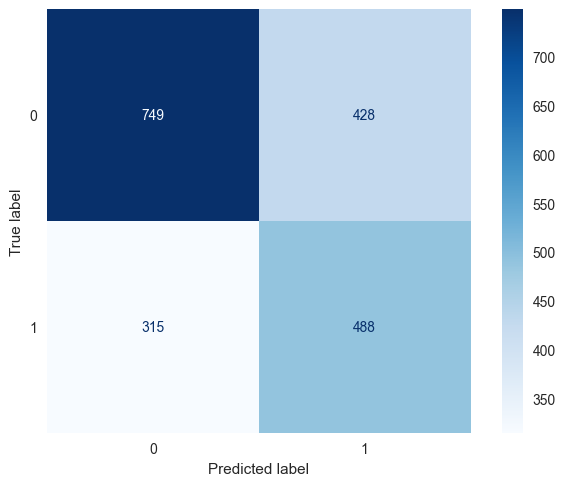

In [55]:
test_pred = clf_main.predict(X_test_main)
    
print(classification_report(y_test_main, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf_main, X_test_main, y_test_main, cmap = plt.cm.Blues)
plt.grid(False)
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.69      0.75      1501
           1       0.43      0.62      0.51       576

    accuracy                           0.67      2077
   macro avg       0.63      0.65      0.63      2077
weighted avg       0.72      0.67      0.68      2077



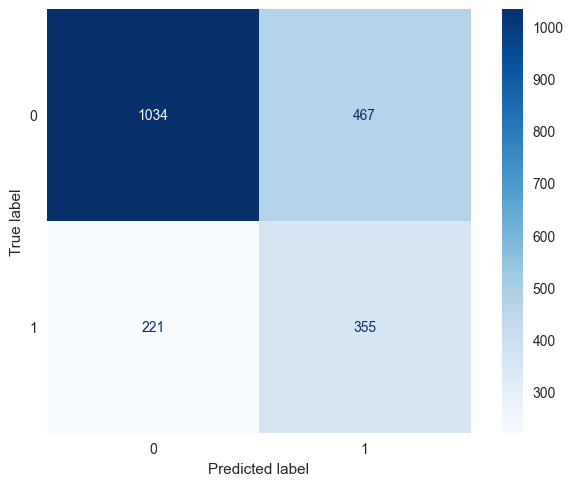

In [56]:
test_pred = clf_extra.predict(X_test_extra)
    
print(classification_report(y_test_extra, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf_extra, X_test_extra, y_test_extra, cmap = plt.cm.Blues)
plt.grid(False)
plt.show()

**Observations:**
- Overall the precision, recall and f1 score values are showing just above average performance in the SVM model.
- Interestingly the weighted average and even accuracy scores are slightly better than the macro averaged, even with the unbalanced classes.
- The model for both sets have close to inverse true label counts when predicting cancerous. I.e. Main set: 399 (0) / 474 (1) vs. Extra set: 453 / 333.

# Baseline Convolutional Neural Network model (isCancerous)

In [13]:
from torch.utils.data import ConcatDataset

# Again concat the train and val datasets for training
trainval_dataset_main = ConcatDataset([train_dataset_main, val_dataset_main])

trainval_loader_main = DataLoader(trainval_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)

trainval_dataset_extra = ConcatDataset([train_dataset_extra, val_dataset_extra])

trainval_loader_extra = DataLoader(trainval_dataset_extra, batch_size=batch_size, shuffle=True, num_workers=0)

In [14]:
import torch.nn as nn

# No GPU available
device = torch.device('cpu')
print('Using device:', device)

# Try VGGNet architecture
class VGGNet(nn.Module):
    def __init__(self, output_classes, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # 27 -> 13
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # 13 -> 6
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # 6 -> 3
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 1152 -> 128
            nn.Linear(128 * 3 * 3, 128),  
            nn.ReLU(inplace=True),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(128, output_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Using device: cpu


In [ ]:
# # addresses class imbalance
# from sklearn.utils.class_weight import compute_class_weight

# classes = np.array([0, 1])
# y_train = train_data_main['isCancerous'].values
# weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# class_weights = torch.FloatTensor(weights).to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights)

# Balances too much and makes it drop in accuracy; means predicts more not cancerous however (same idea of celltype)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=25, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim = 1)
                val_correct += (preds == labels).sum().item()
                val_samples += images.size(0)

        val_loss /= val_samples
        val_acc = val_correct / val_samples

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        print(
            f'Epoch {epoch + 1} / {epochs} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, '
            f'train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}'
        )

    return history

OUTPUT_CLASSES = 2
model_VGG_1 = VGGNet(output_classes=OUTPUT_CLASSES, dropout=0.0)

In [76]:
print(model_VGG_1)

VGGNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear

In [77]:
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel('epochs')
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid(True)
    
    plt.show()

In [93]:
# Train on images
history_VGG_1 = train_model(model_VGG_1, trainval_loader_main, test_loader_main, epochs=25, lr=1e-3, weight_decay=0.0)
print('Training complete!')

Epoch 1 / 25 — train_loss: 0.3281, val_loss: 0.2670, train_acc: 0.8953, val_acc: 0.9056
Epoch 2 / 25 — train_loss: 0.1864, val_loss: 0.2859, train_acc: 0.9256, val_acc: 0.8879
Epoch 3 / 25 — train_loss: 0.1388, val_loss: 0.3245, train_acc: 0.9449, val_acc: 0.8929
Epoch 4 / 25 — train_loss: 0.0952, val_loss: 0.3819, train_acc: 0.9639, val_acc: 0.8859
Epoch 5 / 25 — train_loss: 0.0877, val_loss: 0.3856, train_acc: 0.9677, val_acc: 0.8955
Epoch 6 / 25 — train_loss: 0.0723, val_loss: 0.4196, train_acc: 0.9735, val_acc: 0.8783
Epoch 7 / 25 — train_loss: 0.0600, val_loss: 0.4578, train_acc: 0.9787, val_acc: 0.8980
Epoch 8 / 25 — train_loss: 0.0348, val_loss: 0.5421, train_acc: 0.9890, val_acc: 0.8884
Epoch 9 / 25 — train_loss: 0.0544, val_loss: 0.4148, train_acc: 0.9800, val_acc: 0.8960
Epoch 10 / 25 — train_loss: 0.0239, val_loss: 0.5522, train_acc: 0.9920, val_acc: 0.8904
Epoch 11 / 25 — train_loss: 0.0308, val_loss: 0.4990, train_acc: 0.9903, val_acc: 0.8939
Epoch 12 / 25 — train_loss: 0.

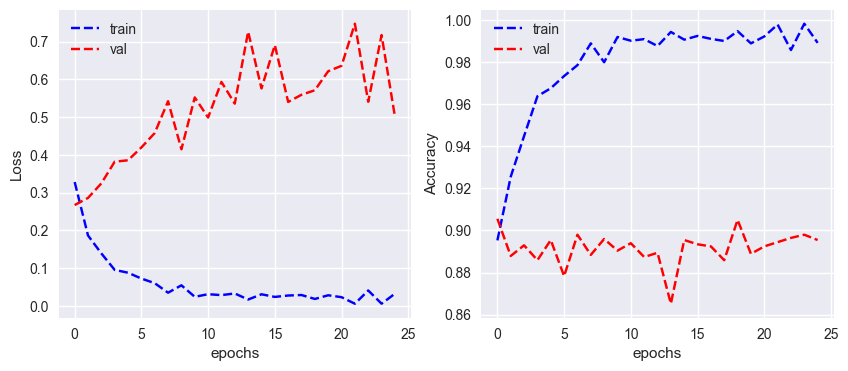

In [94]:
plot_learning_curve(history_VGG_1['loss'], history_VGG_1['val_loss'], history_VGG_1['accuracy'], history_VGG_1['val_accuracy'], 
    metric_name='Accuracy'
)

In [89]:
# Train on images (Extra)
history_VGG_2 = train_model(model_VGG_1, trainval_loader_extra, test_loader_extra, epochs=25, lr=1e-3, weight_decay=0.0)
print('Training complete!')

Epoch 1 / 25 — train_loss: 0.0186, val_loss: 0.5005, train_acc: 0.9935, val_acc: 0.9027
Epoch 2 / 25 — train_loss: 0.0322, val_loss: 0.3765, train_acc: 0.9896, val_acc: 0.9215
Epoch 3 / 25 — train_loss: 0.0144, val_loss: 0.4095, train_acc: 0.9948, val_acc: 0.9220
Epoch 4 / 25 — train_loss: 0.0071, val_loss: 0.5006, train_acc: 0.9981, val_acc: 0.9220
Epoch 5 / 25 — train_loss: 0.0412, val_loss: 0.3982, train_acc: 0.9844, val_acc: 0.9234
Epoch 6 / 25 — train_loss: 0.0288, val_loss: 0.3358, train_acc: 0.9898, val_acc: 0.9206
Epoch 7 / 25 — train_loss: 0.0256, val_loss: 0.3799, train_acc: 0.9915, val_acc: 0.9090
Epoch 8 / 25 — train_loss: 0.0194, val_loss: 0.4187, train_acc: 0.9937, val_acc: 0.9297
Epoch 9 / 25 — train_loss: 0.0018, val_loss: 0.4547, train_acc: 0.9996, val_acc: 0.9263
Epoch 10 / 25 — train_loss: 0.0002, val_loss: 0.4803, train_acc: 1.0000, val_acc: 0.9292
Epoch 11 / 25 — train_loss: 0.0001, val_loss: 0.5045, train_acc: 1.0000, val_acc: 0.9292
Epoch 12 / 25 — train_loss: 0.

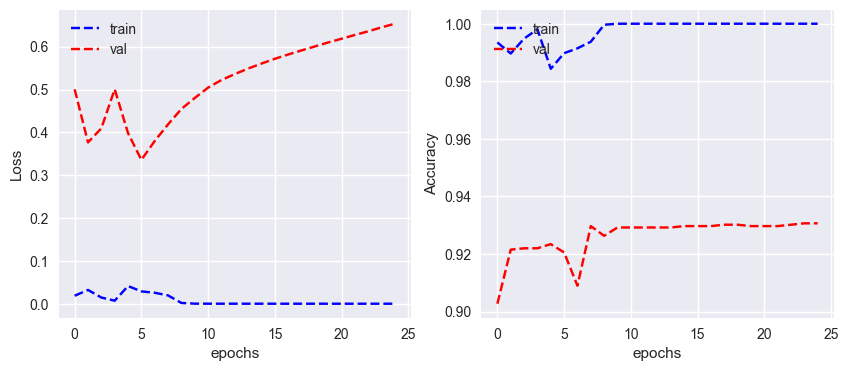

In [90]:
plot_learning_curve(history_VGG_2['loss'], history_VGG_2['val_loss'], history_VGG_2['accuracy'], history_VGG_2['val_accuracy'], 
    metric_name='Accuracy'
)

**Observations:**
- *Main Dataset:*
- Graph seems to show high generalisation gap, but the axies are just very zoomed in.
- As expected it is performing very well (even without adding dropout/weight regularisation or similar) with the highest train accuracy of ~0.99 and validation score of ~0.90.
- It seems as epochs increase, the validation score seems to converge somewhat, which behaves eratically in the first 10 epochs.
- *Extra Dataset:*
- Graph seems to show high generalisation gap, but the axies are just very zoomed in.
- Best performing with no validation scores below 0.9 (highest ~0.93) with converging perfect training scores.
- Seems to converge at high ~0.92 to ~0.93 for validation.

Test Loss: 0.5014
Test Accuracy: 0.8955
Macro F1 Score: 0.8919

              precision    recall  f1-score   support

           0       0.92      0.91      0.91      1177
           1       0.86      0.88      0.87       803

    accuracy                           0.90      1980
   macro avg       0.89      0.89      0.89      1980
weighted avg       0.90      0.90      0.90      1980



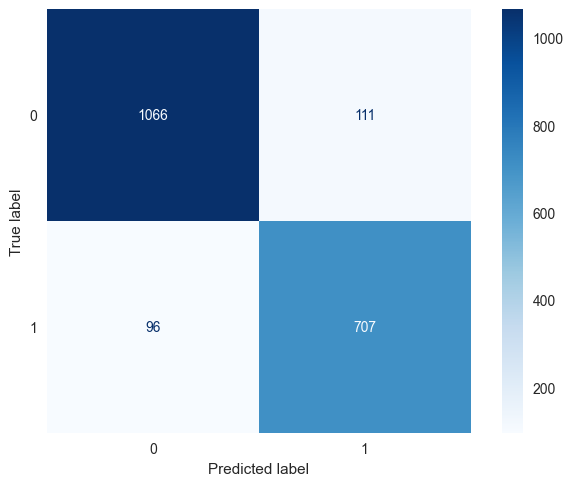

In [95]:
from sklearn.metrics import confusion_matrix

model = model_VGG_1.to(device)
model.eval()
criterion = nn.CrossEntropyLoss()

all_preds = []
all_labels = []
total_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader_main:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

test_loss = total_loss / len(test_loader_main.dataset)
test_acc = (y_pred == y_true).mean()
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')
print()
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.grid(False)
plt.show()

Test Loss: 0.6536
Test Accuracy: 0.9307
Macro F1 Score: 0.9130

              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1501
           1       0.88      0.87      0.87       576

    accuracy                           0.93      2077
   macro avg       0.92      0.91      0.91      2077
weighted avg       0.93      0.93      0.93      2077



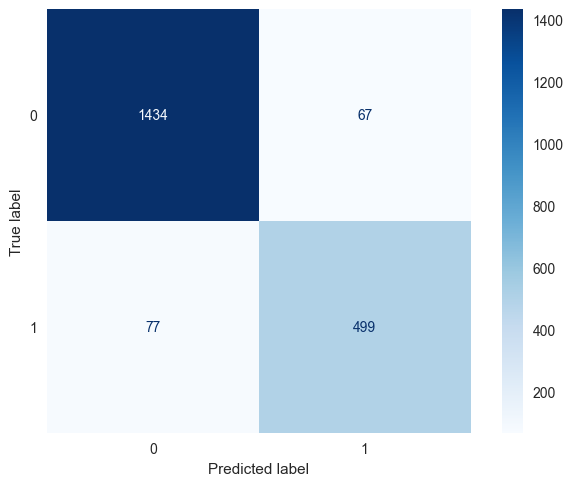

In [92]:
from sklearn.metrics import confusion_matrix

model = model_VGG_1.to(device)
model.eval()
criterion = nn.CrossEntropyLoss()

all_preds = []
all_labels = []
total_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader_extra:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

test_loss = total_loss / len(test_loader_extra.dataset)
test_acc = (y_pred == y_true).mean()
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')
print()
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.grid(False)
plt.show()

**Observations:**
- Again performing well. This shows that the CNN is able to generalise patterns from the image data.
- Similar confusion matrixes for both sets, both majorly predicting the actual labels.

# cellTypeName Task
0 -> fibroblast; 1 -> inflammatory; 2 -> epithelial; 3 -> others
# Data Splitting
## Random splitting (Hold-out validation)

In [10]:
from sklearn.model_selection import train_test_split
# As per the task use Hold-out validation (60/20/20)

# Remove isCancerous as per the task is analysed separately
X_temp, X_test_main, y_temp, y_test_main = train_test_split(cellsMainFrame.drop(['ImageName', 'cellType', 'isCancerous'], axis=1), 
    cellsMainFrame['cellType'], test_size=0.2, shuffle=True, random_state=0
)
X_train_main, X_val_main, y_train_main, y_val_main = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=True, random_state=0)

# Handle images separately
train_data_main, test_data_main = train_test_split(cellsMainFrame.drop(['InstanceID', 'patientID', 'isCancerous'], axis=1), test_size=0.2, 
    random_state=0
)
train_data_main, val_data_main = train_test_split(train_data_main, test_size=0.25, shuffle=True, random_state=0)

print('Main Dataset:')
print(f'Train size: {X_train_main.shape[0]}')
print(f'Validation size: {X_val_main.shape[0]}')
print(f'Test size: {X_test_main.shape[0]}')

Main Dataset:
Train size: 5937
Validation size: 1979
Test size: 1980


In [11]:
import torch
from tqdm import tqdm

# First extract flattened features from dataloader
def extract_flat_features(dataloader):
    all_features = []
    all_labels = []

    for imgs, lbls in tqdm(dataloader):
        B = imgs.size(0)
        # flatten to (B, 2187) 1-dimensional shape
        feats = imgs.view(B, -1)
        all_features.append(feats)
        all_labels.append(lbls)

    return torch.cat(all_features), torch.cat(all_labels)

In [12]:
from torchvision import transforms

train_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])
val_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize((27, 27)), transforms.ToTensor()])

batch_size = 32

train_dataset_main = CellTypeDataset(train_data_main, './data/images/', transform=train_transform)
val_dataset_main = CellTypeDataset(val_data_main, './data/images/', transform=val_transform)
test_dataset_main = CellTypeDataset(test_data_main, './data/images/', transform=test_transform)

train_loader_main = DataLoader(train_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader_main = DataLoader(val_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader_main = DataLoader(test_dataset_main, batch_size=batch_size, shuffle=False, num_workers=0)

X_train_main_cell, y_train_main_cell = extract_flat_features(train_loader_main)
X_val_main_cell, y_val_main_cell = extract_flat_features(val_loader_main)
X_test_main_cell, y_test_main_cell = extract_flat_features(test_loader_main)

# Combine images with rest of features
X_train_main = np.concatenate([X_train_main.values, X_train_main_cell.numpy()], axis=1)
X_val_main = np.concatenate([X_val_main.values, X_val_main_cell.numpy()], axis=1)
X_test_main = np.concatenate([X_test_main.values, X_test_main_cell.numpy()], axis=1)

100%|██████████| 62/62 [00:02<00:00, 25.41it/s]


# Simple decision tree training

In [20]:
from sklearn import tree

tree_max_depth = 4

# Again train on just X_train if tuning hyperparameters for hold-out
X_train_main = np.concatenate([X_train_main, X_val_main], axis=0)
y_train_main = np.concatenate([y_train_main, y_val_main], axis=0)

# Again class_weight balanced as per unbalanced classes from EDA
clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=tree_max_depth, class_weight='balanced', random_state=0)
clf = clf.fit(X_train_main, y_train_main)

In [14]:
from sklearn.metrics import f1_score

# Macro averaged f1 score to give equal weight to all four classes and as per the task
def get_f1_scores(clf, train_X, train_y, val_X, val_y):
    train_pred = clf.predict(train_X)
    val_pred = clf.predict(val_X)
    
    train_f1 = f1_score(train_y, train_pred, average='macro')
    val_f1 = f1_score(val_y, val_pred, average='macro')
    
    return train_f1, val_f1

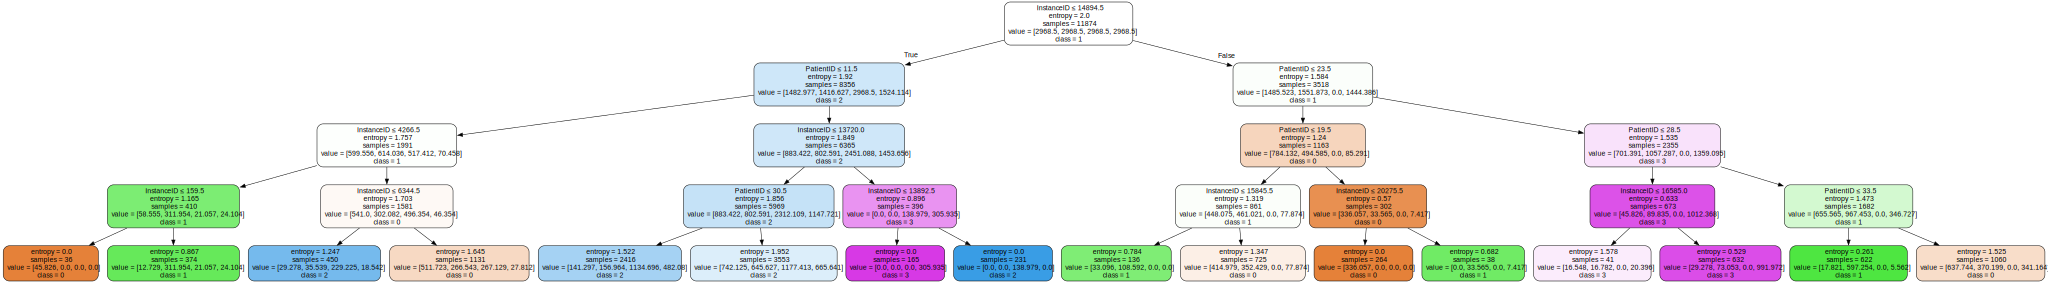

In [21]:
import graphviz

pixel_features = [f'pixel_{i}' for i in range(X_train_main_cell.shape[1])]
meta_features = ['InstanceID', 'PatientID']
feature_names = meta_features + pixel_features

def get_tree_2_plot(clf):
    dot_data = tree.export_graphviz(clf, out_file=None, feature_names=feature_names, class_names=['0', '1', '2', '3'], filled=True, 
        rounded=True, special_characters=True
    )
    graph = graphviz.Source(dot_data)
    
    return graph

DtreeMain = get_tree_2_plot(clf)
DtreeMain

In [22]:
train_f1, test_f1 = get_f1_scores(clf, X_train_main, y_train_main, X_test_main, y_test_main)
print('Train f1 score: {:.3f}'.format(train_f1))
print('Test f1 score: {:.3f}'.format(test_f1))

Train f1 score: 0.603
Test f1 score: 0.604


**Observations:**
- Again the `InstanceID` is the most important feature as it is immediately split at the root, so keeping it seems relevant.
- The root nodes are perfectly balanced across the four classes, which provides the high entropy.
- The `patientID` is again the second most informative feature with both branches.
- No pixels suggest to be important according to this DT with depth 5.
- There is some slight overfitting with the results; could be improved by tuning as above such as increasing depth.
- The training and validation scores are quite similar, but with low predictability could benefit from a random forest ensemble for combining multiple trees.

              precision    recall  f1-score   support

           0       0.44      0.64      0.52       372
           1       0.92      0.38      0.54       504
           2       0.67      0.90      0.77       803
           3       0.86      0.44      0.58       301

    accuracy                           0.65      1980
   macro avg       0.72      0.59      0.60      1980
weighted avg       0.72      0.65      0.64      1980



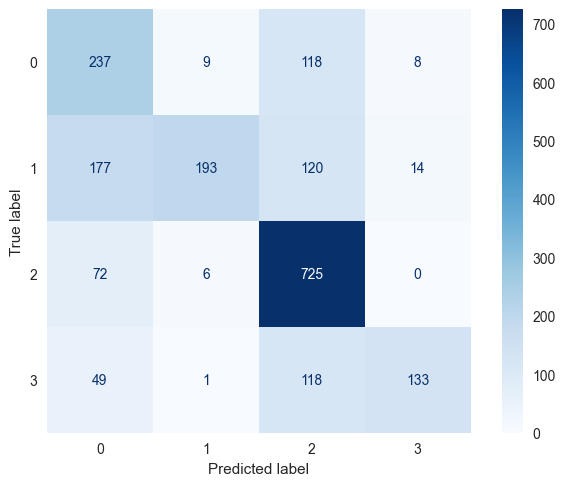

In [23]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

test_pred = clf.predict(X_test_main)

print(classification_report(y_test_main, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test_main, y_test_main, cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

**Observations:**
- Matrix reflects performance, however predicted 0 labels for type 3 when it is actually type 2. I.e. only narrowing it down to 0, 3 and only 6 labels for 1.

## Feature importance

<Figure size 1000x1000 with 0 Axes>

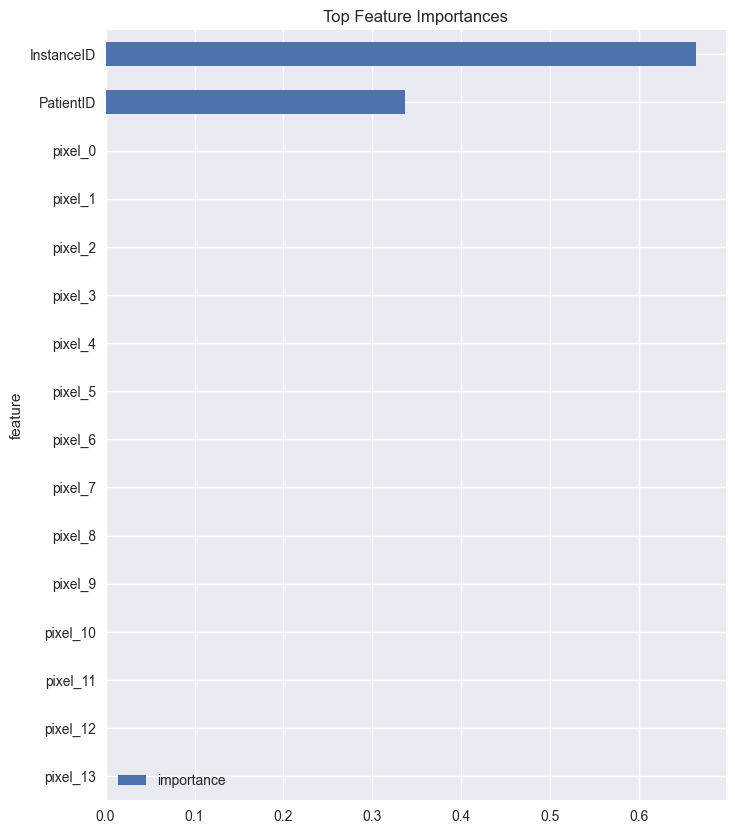

In [17]:
tree_feature_importances = clf.feature_importances_

plt.figure(figsize=(10, 10))
fi = pd.DataFrame({'feature': feature_names, 'importance': tree_feature_importances}).sort_values('importance', ascending=False)

top_k = 16
fi.head(top_k).plot(kind='barh', x='feature', y='importance', figsize=(8, 10))
plt.gca().invert_yaxis()
plt.title('Top Feature Importances')
plt.show()

**Observations:**
- The model seems to only heavily rely on `InstanceID` and `patientID` to predict the target.
- It seems there are no other attributes (i.e. images pixels) it heavily relies on, even though this is an image classification task.
- This could mean the images generate a lot of unecessary noise and do not have a good relationship with the target for this DT model.

# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Use gini criterion for faster computations on 500 trees and balanced_subsample for adapting to different distributions from its sample
clf = RandomForestClassifier(max_depth=10, n_estimators=500, class_weight='balanced_subsample', random_state=0)
clf.fit(X_train_main, y_train_main)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [27]:
train_f1, test_f1 = get_f1_scores(clf, X_train_main, y_train_main, X_test_main, y_test_main)
print('Train f1 score: {:.3f}'.format(train_f1))
print('Test f1 score: {:.3f}'.format(test_f1))

Train f1 score: 0.978
Test f1 score: 0.319


              precision    recall  f1-score   support

           0       0.23      0.06      0.10       372
           1       0.41      0.37      0.39       504
           2       0.57      1.00      0.73       803
           3       0.38      0.03      0.06       301

    accuracy                           0.52      1980
   macro avg       0.40      0.37      0.32      1980
weighted avg       0.44      0.52      0.42      1980



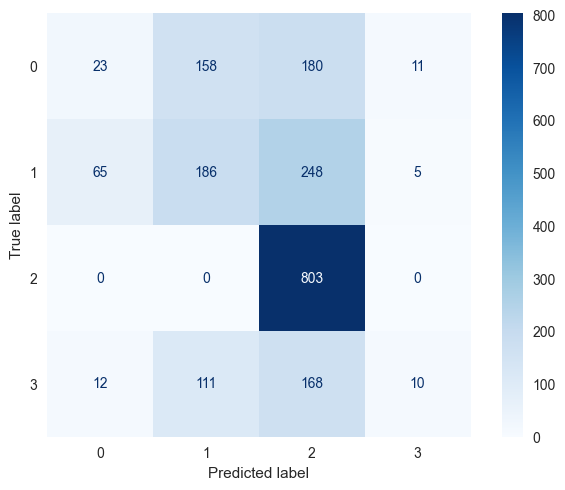

In [28]:
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

test_pred = clf.predict(X_test_main)

print(classification_report(y_test_main, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test_main, y_test_main, cmap=plt.cm.Blues)
plt.grid(False)
plt.show()

**Observations:**
- The RF is severely overfitting with a training score of 0.978 and testing score of 0.319.
- It does however do a better job than the normal DT at predicting cell type 2 with 0 predictions for the other labels i.e. 0, 1 and 3.
- DT performed the best out of the tree models in terms of predicting cell types with higher test score of 0.403 untuned, compared to 0.319 with semi-tuned RF.
- Could tune more but also explain why this occurs for this advanced technique.

## Feature importance

<Figure size 1000x1000 with 0 Axes>

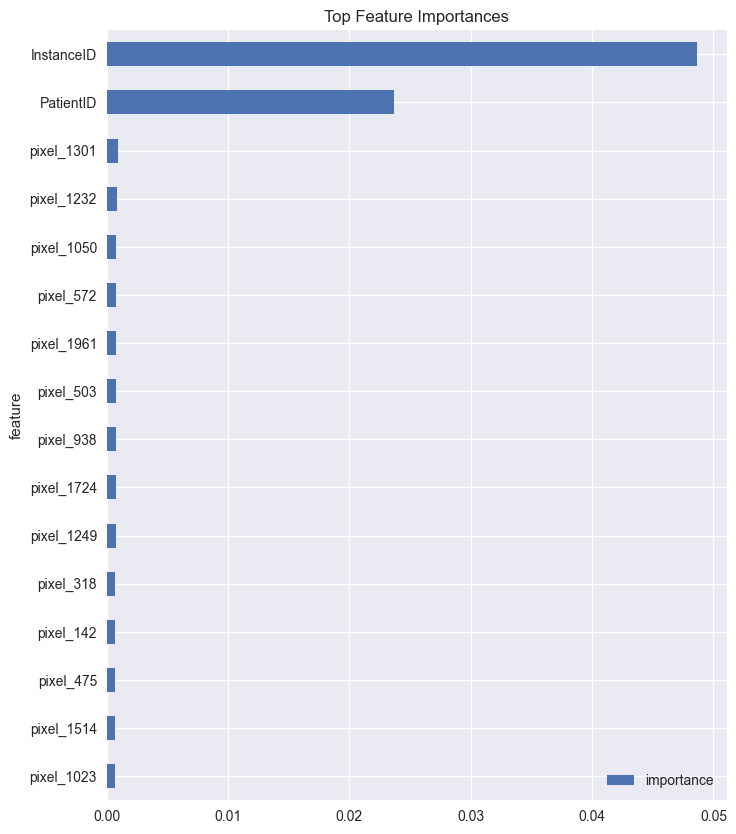

In [20]:
tree_feature_importances = clf.feature_importances_

plt.figure(figsize=(10, 10))
fi = pd.DataFrame({'feature': feature_names, 'importance': tree_feature_importances}).sort_values('importance', ascending=False)

top_k = 16
fi.head(top_k).plot(kind='barh', x='feature', y='importance', figsize=(8, 10))
plt.gca().invert_yaxis()
plt.title('Top Feature Importances')
plt.show()

**Observations:**
- The RF model again majorly relies on `InstanceID` and `patientID` as well as pixels to predict the target.
- It seems to somewhat rely on all features (small amount of pixels) unlike the DT where it seems to not rely much on pixels.

# Baseline SVM model (cellTypeName)

In [60]:
# Applying Standard Scaler is recommended as it reduces sensitivity to extreme outliers in the attributes (incl. pixels)
# Also no need for transforms.Normalize in the DataLoader as we scale all incl. metadata here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_main)

X_train_main = scaler.transform(X_train_main)
X_test_main = scaler.transform(X_test_main)

## Testing the model

In [61]:
from sklearn.svm import LinearSVC

clf_main = LinearSVC(C=1.0, random_state=0, class_weight='balanced')
clf_main.fit(X_train_main, y_train_main)

train_f1, test_f1 = get_f1_scores(clf_main, X_train_main, y_train_main, X_test_main, y_test_main)
print('Train F1-Score score: {:.3f}'.format(train_f1))
print('Test F1-Score score: {:.3f}'.format(test_f1))

Train F1-Score score: 0.822
Test F1-Score score: 0.303


**Observations:**
- Higher training score, so overfitting with not great validation score.
- Performed slightly worse in terms of validation scores for the DT (depth 4) (~0.6 vs ~0.3).
- Again could be improved by hyperparameter tuning.

              precision    recall  f1-score   support

           0       0.23      0.26      0.24       372
           1       0.26      0.24      0.25       504
           2       0.52      0.47      0.50       803
           3       0.20      0.25      0.22       301

    accuracy                           0.34      1980
   macro avg       0.30      0.31      0.30      1980
weighted avg       0.35      0.34      0.34      1980



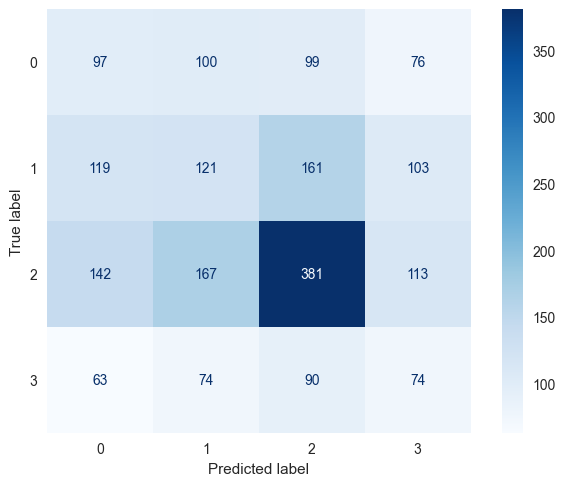

In [62]:
test_pred = clf_main.predict(X_test_main)
    
print(classification_report(y_test_main, test_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf_main, X_test_main, y_test_main, cmap = plt.cm.Blues)
plt.grid(False)
plt.show()

**Observations:**
- Overall the precision, recall and f1 score values are showing below average performance in the SVM model.
- Again, the weighted average and even accuracy scores are slightly better than the macro averaged, even with the unbalanced classes.
- When the model predicts type 2, it is mostly accurately type 2.

# Baseline Convolutional Neural Network model (cellTypeName)

In [ ]:
from torch.utils.data import ConcatDataset

# Again concat the train and val datasets for training
trainval_dataset_main = ConcatDataset([train_dataset_main, val_dataset_main])

trainval_loader_main = DataLoader(trainval_dataset_main, batch_size=batch_size, shuffle=True, num_workers=0)

In [65]:
import torch.nn as nn

# No GPU available
device = torch.device('cpu')
print('Using device:', device)

# Try VGGNet architecture
class VGGNet(nn.Module):
    def __init__(self, output_classes, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # 27 -> 13
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # 13 -> 6
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            # 6 -> 3
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 1152 -> 128
            nn.Linear(128 * 3 * 3, 128),  
            nn.ReLU(inplace=True),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(128, output_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Using device: cpu


In [66]:
def train_model(model, train_loader, val_loader, epochs=25, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim = 1)
                val_correct += (preds == labels).sum().item()
                val_samples += images.size(0)

        val_loss /= val_samples
        val_acc = val_correct / val_samples

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        print(
            f'Epoch {epoch + 1} / {epochs} — train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, '
            f'train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}'
        )

    return history

OUTPUT_CLASSES = 4
model_VGG_2 = VGGNet(output_classes=OUTPUT_CLASSES, dropout=0.0)

In [67]:
print(model_VGG_2)

VGGNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear

In [68]:
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel('epochs')
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid(True)
    
    plt.show()

In [69]:
# Train on images
history_VGG_3 = train_model(model_VGG_2, trainval_loader_main, test_loader_main, epochs=25, lr=1e-3, weight_decay=0.0)
print('Training complete!')

Epoch 1 / 25 — train_loss: 1.1859, val_loss: 0.9561, train_acc: 0.4812, val_acc: 0.5737
Epoch 2 / 25 — train_loss: 0.9435, val_loss: 0.9706, train_acc: 0.5963, val_acc: 0.6086
Epoch 3 / 25 — train_loss: 0.8199, val_loss: 0.7959, train_acc: 0.6823, val_acc: 0.6864
Epoch 4 / 25 — train_loss: 0.7304, val_loss: 0.6834, train_acc: 0.7141, val_acc: 0.7242
Epoch 5 / 25 — train_loss: 0.6976, val_loss: 0.7200, train_acc: 0.7249, val_acc: 0.7020
Epoch 6 / 25 — train_loss: 0.6693, val_loss: 0.6547, train_acc: 0.7329, val_acc: 0.7505
Epoch 7 / 25 — train_loss: 0.6362, val_loss: 0.6223, train_acc: 0.7514, val_acc: 0.7591
Epoch 8 / 25 — train_loss: 0.6280, val_loss: 0.6694, train_acc: 0.7585, val_acc: 0.7379
Epoch 9 / 25 — train_loss: 0.6029, val_loss: 0.6147, train_acc: 0.7639, val_acc: 0.7626
Epoch 10 / 25 — train_loss: 0.5728, val_loss: 0.6044, train_acc: 0.7726, val_acc: 0.7646
Epoch 11 / 25 — train_loss: 0.5526, val_loss: 0.5873, train_acc: 0.7885, val_acc: 0.7697
Epoch 12 / 25 — train_loss: 0.

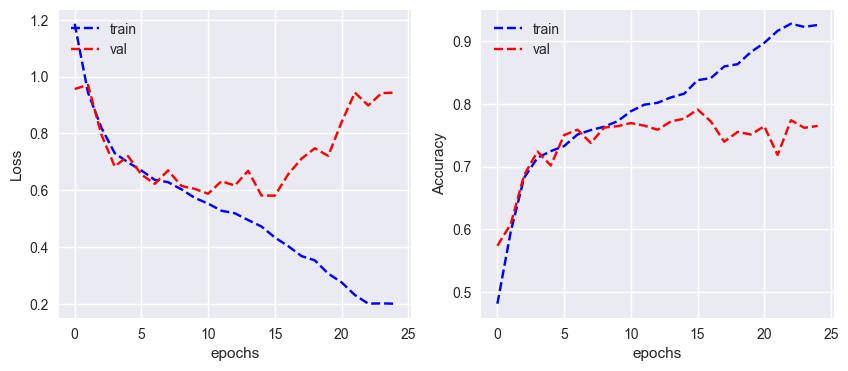

In [70]:
plot_learning_curve(history_VGG_3['loss'], history_VGG_3['val_loss'], history_VGG_3['accuracy'], history_VGG_3['val_accuracy'], 
    metric_name='Accuracy'
)

**Observations:**
- Generalisation gap starts to show at ~10 epochs.
- As expected it is performing very well (even without adding dropout/weight regularisation or similar) with the highest train accuracy of ~0.93 and validation score of ~0.79.
- Seems to converge at ~0.7 for validation.

Test Loss: 0.9434
Test Accuracy: 0.7652
Macro F1 Score: 0.7106

              precision    recall  f1-score   support

           0       0.73      0.70      0.71       372
           1       0.71      0.78      0.74       504
           2       0.81      0.93      0.87       803
           3       0.75      0.40      0.52       301

    accuracy                           0.77      1980
   macro avg       0.75      0.70      0.71      1980
weighted avg       0.76      0.77      0.75      1980



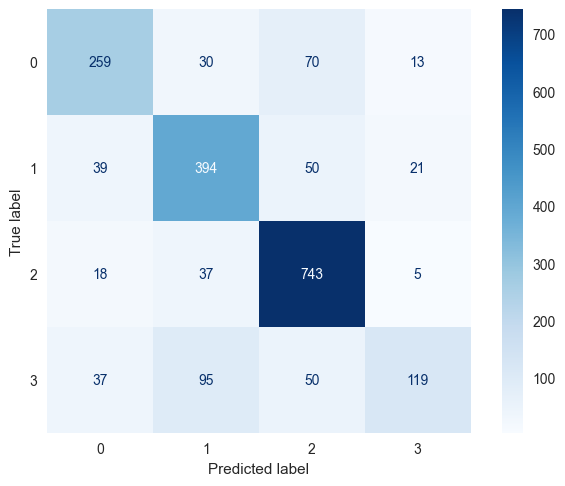

In [71]:
from sklearn.metrics import confusion_matrix

model = model_VGG_2.to(device)
model.eval()
criterion = nn.CrossEntropyLoss()

all_preds = []
all_labels = []
total_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader_main:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

test_loss = total_loss / len(test_loader_main.dataset)
test_acc = (y_pred == y_true).mean()
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')
print()
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.grid(False)
plt.show()

**Observations:**
- Again performing well. This shows that the CNN is able to generalise patterns from the image data.
- Majorly predicting the actual labels, with 95 labels predicting type 1 where it is actually type 3.

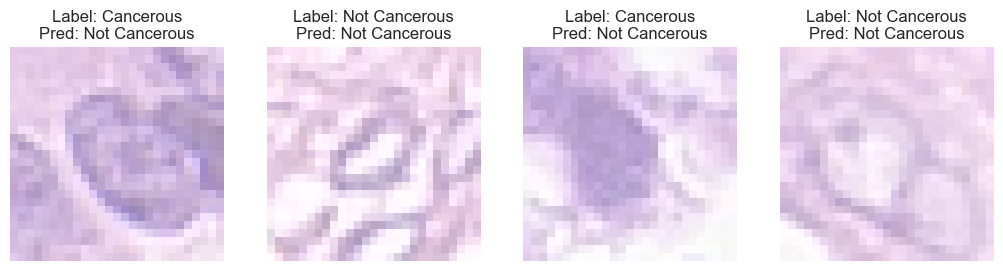

In [33]:
label_names = {0: 'Not Cancerous', 1: 'Cancerous'}

plt.figure(figsize=(16, 4))
model_VGG_1.to(device).eval()

shown = 0

with torch.no_grad():
    for images, labels in test_loader_main:
        images = images.to(device)
        outputs = model_VGG_1.to(device)(images)
        preds = torch.argmax(outputs, dim=1)

        # Loop through images in the batch
        for i in range(images.size(0)):
            if shown == 4:
                break

            img = images[i].cpu().permute(1, 2, 0).numpy()

            # If normalized to [-1, 1], denormalize
            img = (img + 1) / 2
            img = np.clip(img, 0, 1)

            plt.subplot(1, 5, shown + 1)
            plt.imshow(img)
            plt.title(f'Label: {label_names[labels[i].item()]}\nPred: {label_names[preds[i].item()]}')
            plt.axis('off')

            shown += 1

        if shown == 4:
            break

plt.show()